In [1]:
## install finrl library
!pip install wrds
!pip install swig
!pip install -q condacolab
import condacolab
condacolab.install()
!apt-get update -y -qq && apt-get install -y -qq cmake libopenmpi-dev python3-dev zlib1g-dev libgl1-mesa-glx swig
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git

  Using cached swig-4.3.1-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (3.5 kB)
Using cached swig-4.3.1-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.9 MB)
✨🍰✨ Everything looks OK!
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
  Cloning https://github.com/AI4Finance-Foundation/FinRL.git to /tmp/pip-req-build-g3z9bttj
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/FinRL.git /tmp/pip-req-build-g3z9bttj
  Resolved https://github.com/AI4Finance-Foundation/FinRL.git to commit 69776b349ee4e63efe3826f318aef8e5c5f59648
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/AI4Finance-Foundation/ElegantRL.git to /tmp/pip-install-z938ko9r/elegantrl_7ce51ea4d0f24a13832

In [2]:
!pip install pandas_market_calendars

In [29]:
import pandas as pd
df = pd.read_csv("train_with_sentiment.csv", index_col=0)


In [30]:
import os
import pandas as pd

from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from stable_baselines3.common.logger import configure
from finrl import config_tickers
from finrl.main import check_and_make_directories
from finrl.config import INDICATORS, TRAINED_MODEL_DIR, RESULTS_DIR

check_and_make_directories([TRAINED_MODEL_DIR])


In [31]:
train = df


In [10]:
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

# Define the technical indicators list (including sentiment and others)
tech_indicators = ['macd', 'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30',
                   'close_30_sma', 'close_60_sma', 'vix', 'turbulence', 'sentiment_2w']

stock_dim = len(train['tic'].unique())
state_space = 1 + 2*stock_dim + stock_dim*len(tech_indicators)
action_space = stock_dim

env = StockTradingEnv(
    df=train,
    stock_dim=stock_dim,
    hmax=100,
    initial_amount=1_000_000,
    num_stock_shares=[0]*stock_dim,
    buy_cost_pct=[0.001]*stock_dim,
    sell_cost_pct=[0.001]*stock_dim,
    reward_scaling=1e-4,
    state_space=state_space,
    action_space=action_space,
    tech_indicator_list=tech_indicators,
    print_verbosity=50,
    turbulence_threshold=None,
    risk_indicator_col="turbulence"
)


In [11]:
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np

class EpisodeLogger(BaseCallback):
    def __init__(self, log_interval=50, verbose=1):
        super().__init__(verbose)
        self.log_interval = log_interval

        # Lists to store episode-level metrics
        self.episodes    = []
        self.end_values  = []
        self.end_rewards = []
        self.end_trades  = []
        self.end_sharpes = []

    def _on_step(self) -> bool:
        # print a snapshot every log_interval steps
        if self.n_calls % self.log_interval == 0:
            env = self.training_env.envs[0]
            state    = env.state
            cash     = state[0]
            prices   = state[1:1+env.stock_dim]
            holdings = state[1+env.stock_dim:1+2*env.stock_dim]
            stock_value  = sum(p*h for p,h in zip(prices, holdings))
            total_asset  = cash + stock_value
            num_pos      = sum(1 for h in holdings if h>0)
            trades       = env.trades

            print(
                f"[Step {self.n_calls:5d}] "
                f"Day {env.day:4d} | "
                f"Asset=${total_asset:,.2f} | "
                f"Cash=${cash:,.2f} | "
                f"Positions={num_pos} | "
                f"Trades={trades}"
            )
        return True

    def _on_rollout_end(self) -> None:
        # called at the end of each episode
        env    = self.training_env.envs[0]
        assets = np.array(env.asset_memory)  # array of portfolio values over time

        # Episode index
        self.episodes.append(env.episode)

        # Final portfolio value
        final_val = assets[-1]
        self.end_values.append(final_val)

        # Total reward = final – initial
        self.end_rewards.append(final_val - assets[0])

        # Total trades in this episode
        self.end_trades.append(env.trades)

        # Compute daily returns and annualized Sharpe ratio
        daily_rets = assets[1:] / assets[:-1] - 1
        if daily_rets.std() > 0:
            sharpe = (daily_rets.mean() / daily_rets.std()) * np.sqrt(252)
        else:
            sharpe = 0.0
        self.end_sharpes.append(sharpe)

    def _on_training_end(self) -> None:
        print(f"\nTraining done: logged {len(self.episodes)} episodes.")


In [12]:
# ppo_scratch_with_logging.py

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_sizes=(64,64)):
        super().__init__()
        layers = []
        last = state_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        self.shared  = nn.Sequential(*layers)
        self.mean    = nn.Linear(last, action_dim)
        self.log_std = nn.Parameter(torch.zeros(action_dim))
        self.value   = nn.Linear(last, 1)

    def forward(self, x):
        x = self.shared(x)
        return self.mean(x), torch.exp(self.log_std), self.value(x)


class PPOAgent:
    def __init__(
        self,
        env,
        gamma=0.99,
        lam=0.95,
        clip_eps=0.2,
        lr=3e-4,
        K_epochs=10,
        batch_size=64,
        update_timestep=2048,
        hidden_sizes=(64,64),
        log_interval=100,
        device=None
    ):
        self.env            = env
        self.gamma          = gamma
        self.lam            = lam
        self.clip_eps       = clip_eps
        self.K_epochs       = K_epochs
        self.batch_size     = batch_size
        self.update_timestep= update_timestep
        self.log_interval   = log_interval
        self.device         = device or ("cuda" if torch.cuda.is_available() else "cpu")

        # Infer dimensions
        obs_shape = env.observation_space.shape
        act_shape = env.action_space.shape
        self.state_dim   = obs_shape[0]
        self.action_dim  = act_shape[0]
        self.act_low     = float(env.action_space.low[0])
        self.act_high    = float(env.action_space.high[0])

        # Networks + optimizer
        self.model      = ActorCritic(self.state_dim, self.action_dim, hidden_sizes).to(self.device)
        self.old_model  = ActorCritic(self.state_dim, self.action_dim, hidden_sizes).to(self.device)
        self.old_model.load_state_dict(self.model.state_dict())
        self.optimizer  = optim.Adam(self.model.parameters(), lr=lr)

        # Experience buffer
        self.reset_buffer()
        self.timestep = 0

        # Logging
        self.episodes    = []
        self.end_values  = []
        self.end_rewards = []
        self.end_trades  = []
        self.end_sharpes = []

    def reset_buffer(self):
        self.states       = []
        self.actions      = []
        self.logprobs     = []
        self.rewards      = []
        self.is_terminals = []
        self.values       = []

    def select_action(self, state):
        # state is guaranteed to be a 1-D numpy array
        state_t = torch.FloatTensor(state).to(self.device)
        mean, std, val = self.old_model(state_t)
        dist = torch.distributions.Normal(mean, std)
        action = dist.sample()
        action_clamped = torch.clamp(action, self.act_low, self.act_high)
        logp = dist.log_prob(action).sum()

        # buffer
        self.states.append(state_t)
        self.actions.append(action)
        self.logprobs.append(logp)
        self.values.append(val.squeeze())

        return action_clamped.cpu().numpy()

    def compute_gae(self, next_value):
        vals = self.values + [next_value]
        gae = 0.0
        returns = []
        for i in reversed(range(len(self.rewards))):
            mask = 1.0 - float(self.is_terminals[i])
            delta = self.rewards[i] + self.gamma * vals[i+1] * mask - vals[i]
            gae = delta + self.gamma * self.lam * mask * gae
            returns.insert(0, gae + vals[i])
        return returns

    def update(self):
        S = torch.stack(self.states).to(self.device)
        A = torch.stack(self.actions).to(self.device)
        L = torch.stack(self.logprobs).to(self.device).detach()
        R = torch.FloatTensor(self.returns).to(self.device)
        V = torch.FloatTensor(self.values).to(self.device)

        adv = (R - V)
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        N = S.size(0)
        for _ in range(self.K_epochs):
            idx = np.arange(N)
            np.random.shuffle(idx)
            for start in range(0, N, self.batch_size):
                b = idx[start:start+self.batch_size]
                m, s, v = self.model(S[b])
                dist = torch.distributions.Normal(m, s)
                logp = dist.log_prob(A[b]).sum(dim=1)
                ratio = (logp - L[b]).exp()

                surr1 = ratio * adv[b]
                surr2 = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * adv[b]
                policy_loss = -torch.min(surr1, surr2).mean()
                value_loss  = nn.MSELoss()(v.squeeze(), R[b])
                loss = policy_loss + 0.5 * value_loss

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

        # sync old policy
        self.old_model.load_state_dict(self.model.state_dict())
        self.reset_buffer()

    def learn(self, total_timesteps, verbose=False):
        # ---- Reset ----
        reset_out = self.env.reset()
        # Gymnasium: reset returns (obs, info), Gym: just obs
        state = reset_out[0] if isinstance(reset_out, tuple) else reset_out
        state = np.asarray(state)  # ensure array

        while self.timestep < total_timesteps:
            # ---- Select & Step ----
            action = self.select_action(state)
            step_out = self.env.step(action)

            # Unpack step
            if len(step_out) == 5:
                obs, reward, term, trunc, _ = step_out
                done = bool(term or trunc)
            else:
                obs, reward, done, _ = step_out

            # Clean up obs/reward/done
            state     = np.asarray(obs)
            reward    = float(reward)
            terminal  = bool(done)

            # Buffer
            self.rewards.append(reward)
            self.is_terminals.append(terminal)
            self.timestep += 1

            # ---- Intra‐episode Logging ----
            if self.timestep % self.log_interval == 0:
                env = self.env
                st  = env.state
                cash = st[0]
                stock_val = sum(
                    p * h for p,h in zip(
                        st[1:1+env.stock_dim],
                        st[1+env.stock_dim:1+2*env.stock_dim]
                    )
                )
                total_asset = cash + stock_val
                num_pos = sum(1 for h in st[1+env.stock_dim:1+2*env.stock_dim] if h>0)
                trades = env.trades
                print(f"[Step {self.timestep:5d}] Day {env.day:4d} | "
                      f"Portf=${total_asset:,.2f} | Cash=${cash:,.2f} | "
                      f"Pos={num_pos} | Trades={trades}")

            # ---- Update on batch ----
            if self.timestep % self.update_timestep == 0:
                with torch.no_grad():
                    next_val = self.model(torch.FloatTensor(state).to(self.device))[2].item()
                self.returns = self.compute_gae(next_val)
                self.update()

            # ---- End of episode ----
            if terminal:
                # record metrics
                env   = self.env
                assets = np.array(env.asset_memory)
                final  = assets[-1]
                self.episodes.append(env.episode)
                self.end_values.append(final)
                self.end_rewards.append(final - assets[0])
                self.end_trades.append(env.trades)
                dr = assets[1:] / assets[:-1] - 1
                sr = (dr.mean()/(dr.std()+1e-8)) * np.sqrt(252)
                self.end_sharpes.append(sr)

                # reset for next episode
                reset_out = env.reset()
                state = reset_out[0] if isinstance(reset_out, tuple) else reset_out
                state = np.asarray(state)

            # ---- Progress logging ----
            if verbose and self.timestep % (total_timesteps // 10) == 0:
                print(f"Progress: {100*self.timestep/total_timesteps:.1f}%")

        print("Training complete.")
        print(f"Logged {len(self.episodes)} episodes.")

    def predict(self, state):
        state_arr = np.asarray(state)
        with torch.no_grad():
            mean, _, _ = self.model(torch.FloatTensor(state_arr).to(self.device))
        action = torch.clamp(mean, self.act_low, self.act_high)
        return action.cpu().numpy()

    def save(self, path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        torch.save(self.model.state_dict(), path)

    def load(self, path):
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.old_model.load_state_dict(self.model.state_dict())


In [13]:
# from ppo_scratch_with_logging import PPOAgent
from stable_baselines3.common.vec_env import DummyVecEnv
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

# 1) Build your FinRL env (raw_env) as before
raw_env = StockTradingEnv(df=train,                     # training data
    stock_dim=stock_dim,
    hmax=100,                        # max 100 shares per trade
    initial_amount=1_000_000,        # $1,000,000 initial cash
    num_stock_shares=[0]*stock_dim,  # start with 0 holdings for each stock
    buy_cost_pct=[0.001]*stock_dim,  # 0.1% buy cost for each stock
    sell_cost_pct=[0.001]*stock_dim, # 0.1% sell cost
    reward_scaling=1e-4,             # scale reward to avoid extreme values
    state_space=state_space,
    action_space=action_space,
    tech_indicator_list=tech_indicators,
    print_verbosity=50,              # print info every 50 steps or episodes (we will adjust usage below)
    turbulence_threshold=None,       # can set a threshold if we want to limit trading in high turbulence
    risk_indicator_col="turbulence")
# 2) Wrap it (or skip wrapping; both work)
# env = DummyVecEnv([lambda: raw_env])

# 3) Instantiate with a log_interval of your choice
agent = PPOAgent(
    env = raw_env,
    gamma=0.99,
    lam=0.95,
    clip_eps=0.2,
    lr=3e-4,
    K_epochs=10,
    batch_size=64,
    update_timestep=2048,
    log_interval=100,    # prints every 100 steps
)

# 4) Train (you’ll now see both the “Step …” logs and end‐of‐episode summaries)
agent.learn(total_timesteps=25000, verbose=True)

# 5) After training, your lists are populated:
#    agent.episodes, agent.end_values, agent.end_rewards, agent.end_trades, agent.end_sharpes

# 6) Save weights
agent.save("ppo_from_scratch.pth")


[Step   100] Day  100 | Portf=$1,059,792.29 | Cash=$2.34 | Pos=14 | Trades=1592
[Step   200] Day  200 | Portf=$1,101,625.07 | Cash=$4.99 | Pos=14 | Trades=3163
[Step   300] Day  300 | Portf=$1,242,285.29 | Cash=$2.39 | Pos=12 | Trades=4775
[Step   400] Day  400 | Portf=$1,403,867.80 | Cash=$2.39 | Pos=12 | Trades=6383
[Step   500] Day  500 | Portf=$1,649,594.53 | Cash=$2.39 | Pos=12 | Trades=8002
[Step   600] Day  600 | Portf=$1,721,351.89 | Cash=$2.39 | Pos=12 | Trades=9639
[Step   700] Day  700 | Portf=$1,831,811.98 | Cash=$2.39 | Pos=12 | Trades=11265
[Step   800] Day   46 | Portf=$1,002,998.17 | Cash=$0.17 | Pos=15 | Trades=786
[Step   900] Day  146 | Portf=$1,093,348.07 | Cash=$19.15 | Pos=13 | Trades=2296
[Step  1000] Day  246 | Portf=$1,177,410.03 | Cash=$12.26 | Pos=12 | Trades=3907
[Step  1100] Day  346 | Portf=$1,265,616.66 | Cash=$12.26 | Pos=12 | Trades=5533
[Step  1200] Day  446 | Portf=$1,490,008.70 | Cash=$12.26 | Pos=12 | Trades=7146
[Step  1300] Day  546 | Portf=$1,724

In [16]:
test_df = pd.read_csv("trade_with_sentiment.csv", index_col=0)

Test: 2019-01-02 → 2019-06-27 | Final=$1,111,067.97 | Return=11.11% | Sharpe=1.85


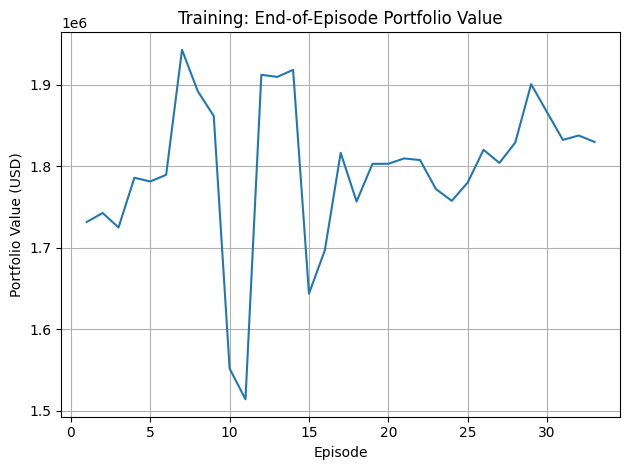

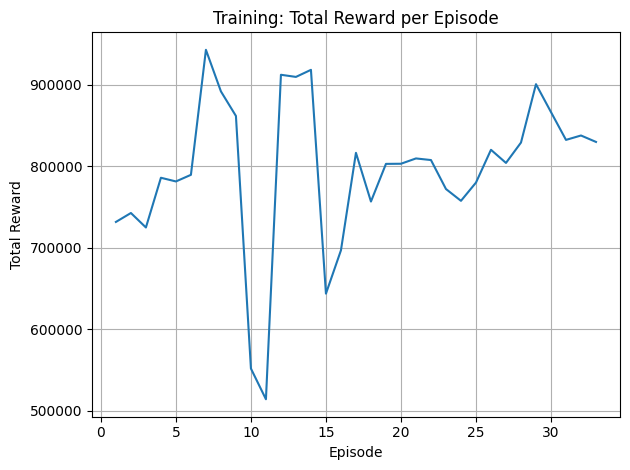

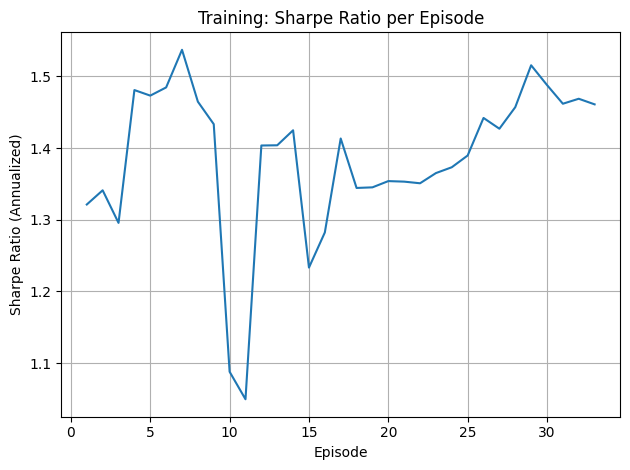

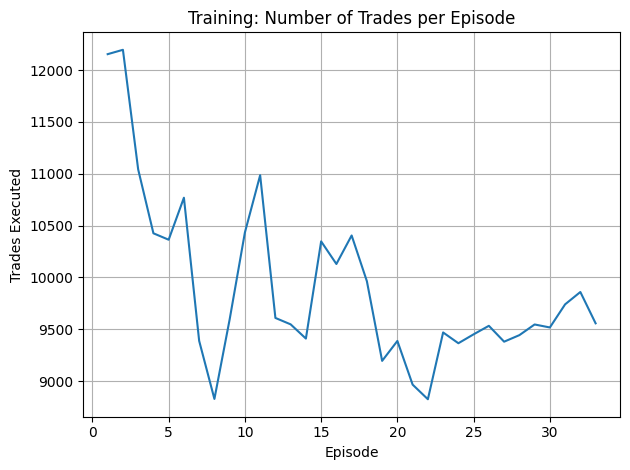

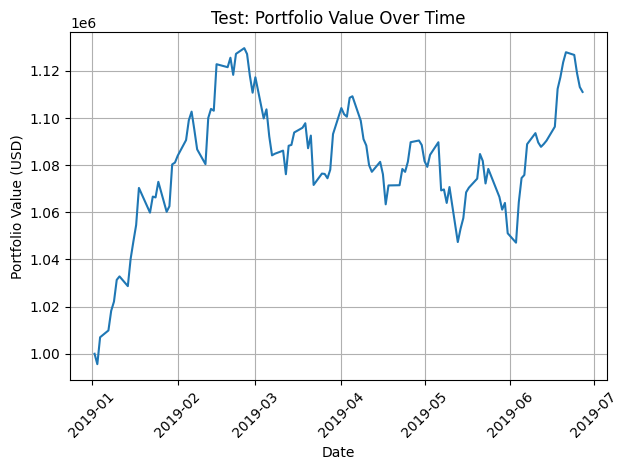

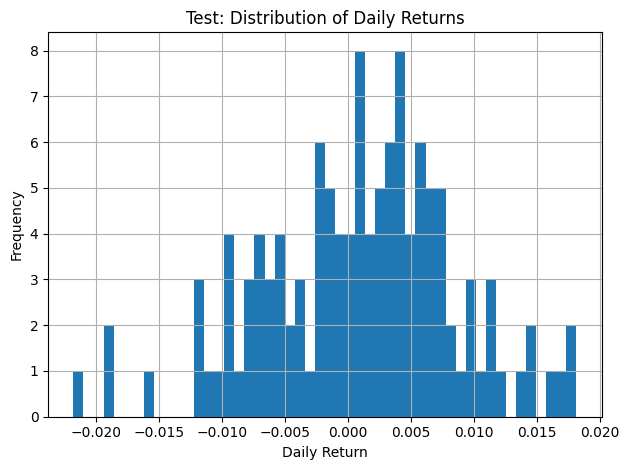

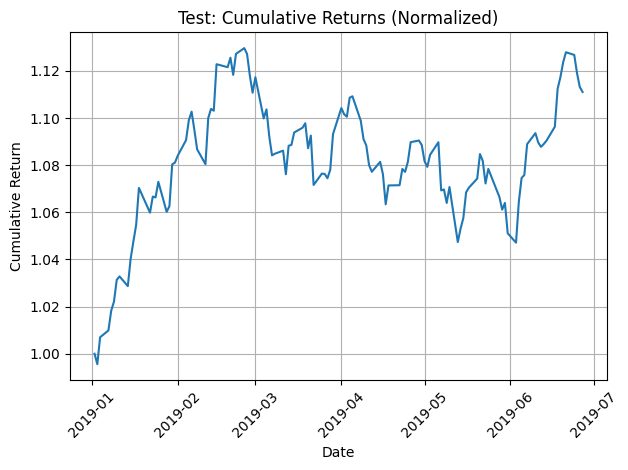

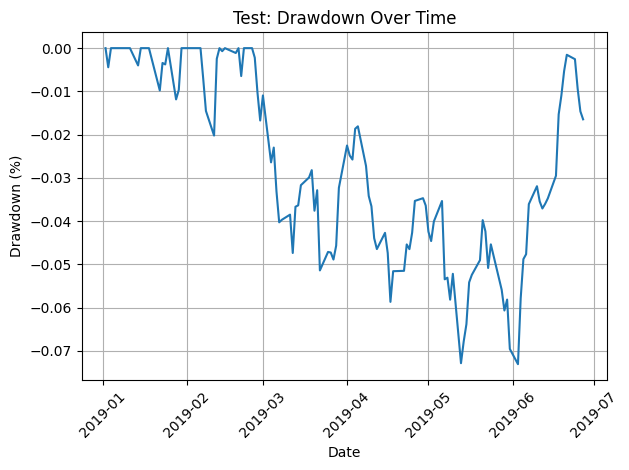

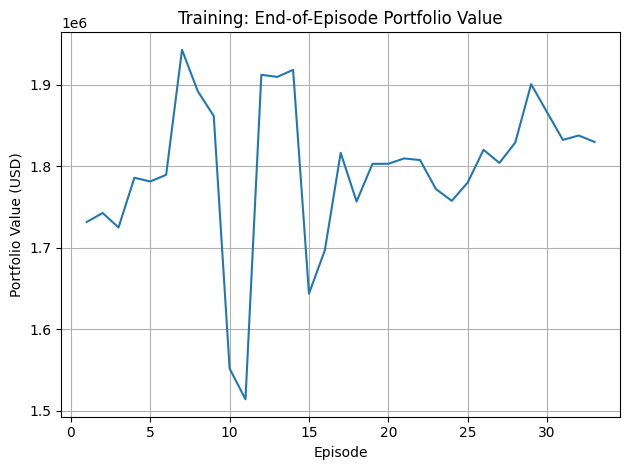

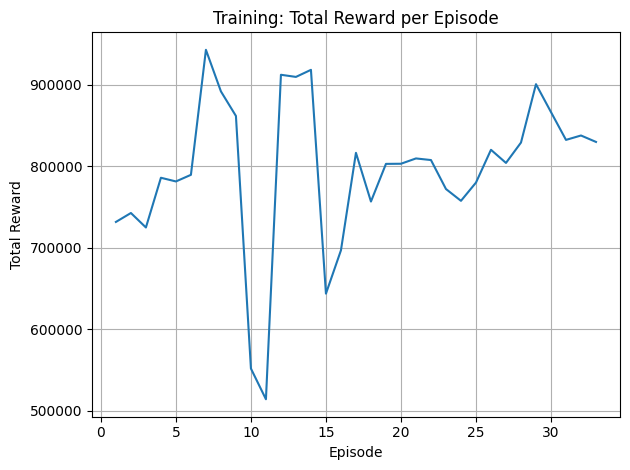

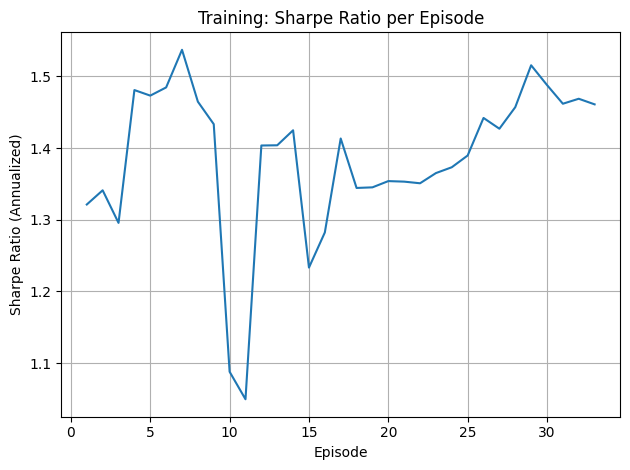

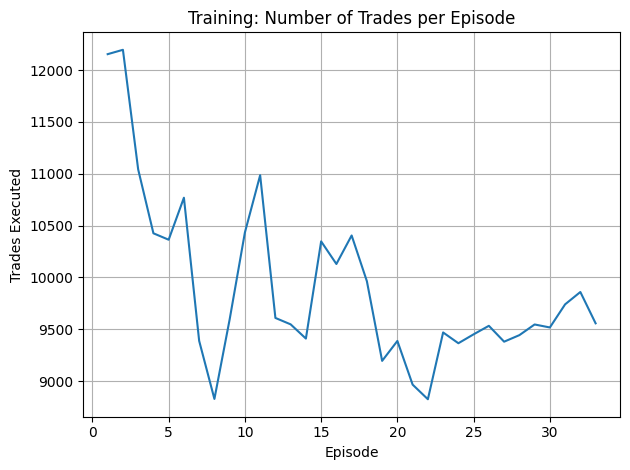

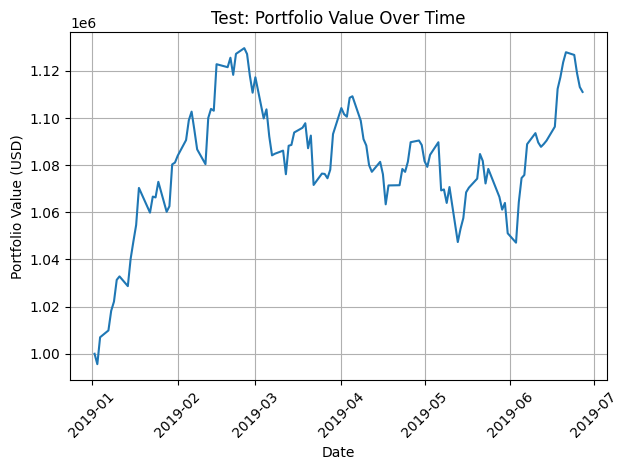

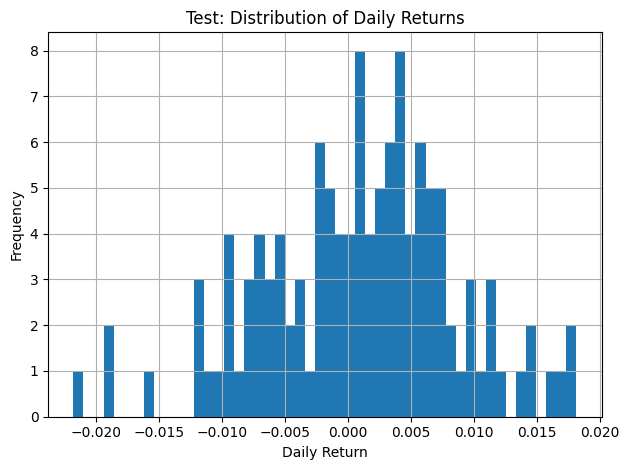

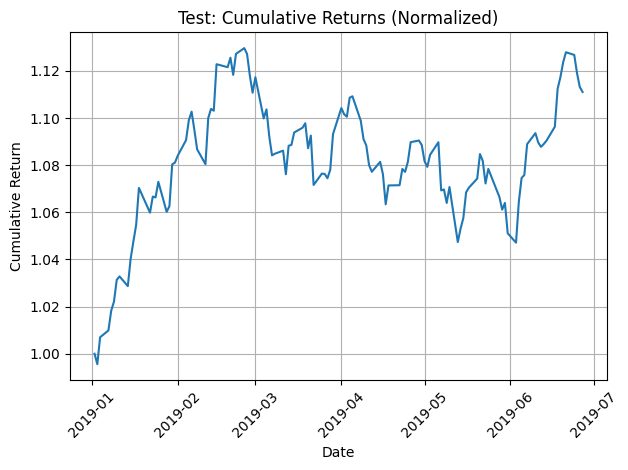

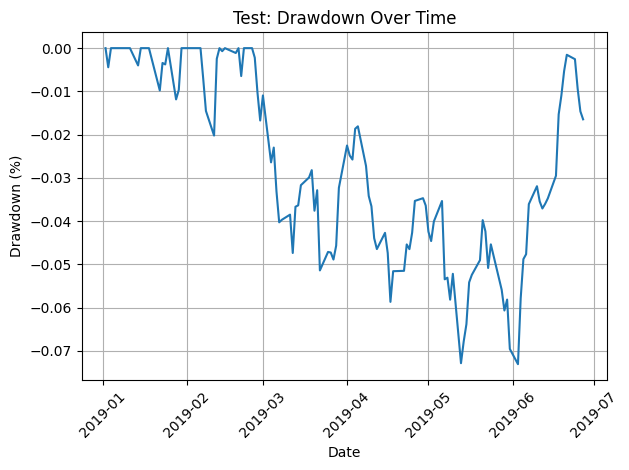

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#make matlotlib inline
%matplotlib inline
# %matplotlib.inline
# 1) Rebuild the test environment
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

test_env = StockTradingEnv(
    df=test_df,                     # your held-out test data
    stock_dim=stock_dim,
    hmax=100,
    initial_amount=1_000_000,
    num_stock_shares=[0]*stock_dim,
    buy_cost_pct=[0.001]*stock_dim,
    sell_cost_pct=[0.001]*stock_dim,
    reward_scaling=1e-4,
    state_space=state_space,
    action_space=action_space,
    tech_indicator_list=tech_indicators,
    print_verbosity=100,
    turbulence_threshold=None,
    risk_indicator_col="turbulence"
)

# 2) Load trained weights
agent.load("ppo_from_scratch.pth")

# 3) Run deterministic test rollout
out = test_env.reset()
state = out[0] if isinstance(out, tuple) else out

done = False
while not done:
    action = agent.predict(state)
    step = test_env.step(action)
    if len(step) == 5:
        obs, reward, term, trunc, _ = step
        done = bool(term or trunc)
    else:
        obs, reward, done, _ = step
    state = obs if not isinstance(obs, tuple) else obs[0]

# 4) Extract test results
test_dates   = pd.to_datetime(test_env.date_memory)
test_assets  = np.array(test_env.asset_memory)
test_actions = test_env.save_action_memory()  # DataFrame indexed by date

# 5) Compute test metrics
daily_rets    = test_assets[1:] / test_assets[:-1] - 1
total_return  = test_assets[-1] / test_assets[0] - 1
sharpe_ratio  = (daily_rets.mean() / (daily_rets.std()+1e-8)) * np.sqrt(252)
print(f"Test: {test_dates[0].date()} → {test_dates[-1].date()} | "
      f"Final=${test_assets[-1]:,.2f} | Return={total_return*100:.2f}% | Sharpe={sharpe_ratio:.2f}")

# -----------------------------------------------------------------------------
# PLOTTING
# -----------------------------------------------------------------------------

# A. Training-phase plots (using your agent's logged lists)
episodes    = agent.episodes
end_values  = agent.end_values
end_rewards = agent.end_rewards
end_trades  = agent.end_trades
end_sharpes = agent.end_sharpes

# 1. End‐of‐episode portfolio value
plt.figure()
plt.plot(episodes, end_values)
plt.title("Training: End-of-Episode Portfolio Value")
plt.xlabel("Episode"); plt.ylabel("Portfolio Value (USD)")
plt.grid(True); plt.tight_layout()
plt.show()

# 2. Total reward per episode
plt.figure()
plt.plot(episodes, end_rewards)
plt.title("Training: Total Reward per Episode")
plt.xlabel("Episode"); plt.ylabel("Total Reward")
plt.grid(True); plt.tight_layout()
plt.show()

# 3. Sharpe ratio per episode
plt.figure()
plt.plot(episodes, end_sharpes)
plt.title("Training: Sharpe Ratio per Episode")
plt.xlabel("Episode"); plt.ylabel("Sharpe Ratio (Annualized)")
plt.grid(True); plt.tight_layout()
plt.show()

# 4. Number of trades per episode
plt.figure()
plt.plot(episodes, end_trades)
plt.title("Training: Number of Trades per Episode")
plt.xlabel("Episode"); plt.ylabel("Trades Executed")
plt.grid(True); plt.tight_layout()
plt.show()


# B. Test-phase plots

# 5. Portfolio value over time
plt.figure()
plt.plot(test_dates, test_assets)
plt.title("Test: Portfolio Value Over Time")
plt.xlabel("Date"); plt.ylabel("Portfolio Value (USD)")
plt.xticks(rotation=45); plt.grid(True); plt.tight_layout()
plt.show()

# 6. Distribution of daily returns
plt.figure()
plt.hist(daily_rets, bins=50)
plt.title("Test: Distribution of Daily Returns")
plt.xlabel("Daily Return"); plt.ylabel("Frequency")
plt.grid(True); plt.tight_layout()
plt.show()

# 7. Cumulative returns (normalized)
cum_ret = test_assets / test_assets[0]
plt.figure()
plt.plot(test_dates, cum_ret)
plt.title("Test: Cumulative Returns (Normalized)")
plt.xlabel("Date"); plt.ylabel("Cumulative Return")
plt.xticks(rotation=45); plt.grid(True); plt.tight_layout()
plt.show()

# 8. Drawdown over time
running_max = np.maximum.accumulate(test_assets)
drawdown    = (test_assets - running_max) / running_max
plt.figure()
plt.plot(test_dates, drawdown)
plt.title("Test: Drawdown Over Time")
plt.xlabel("Date"); plt.ylabel("Drawdown (%)")
plt.xticks(rotation=45); plt.grid(True); plt.tight_layout()
plt.show()

# # 9. Number of positions held over time
# positions = (test_actions.drop(columns=["date"])
#                          .abs()
#                          .gt(0)
#                          .sum(axis=1))
# plt.figure()
# plt.plot(pd.to_datetime(test_actions["date"]), positions)
# plt.title("Test: Number of Stocks Held Over Time")
# plt.xlabel("Date"); plt.ylabel("Number of Positions")
# plt.xticks(rotation=45); plt.grid(True); plt.tight_layout()
# plt.show()

# # 10. Benchmark comparison (if you have a benchmark series)
# #    Uncomment and provide `benchmark_prices` (pd.Series indexed by date)
# # benchmark_norm = benchmark_prices / benchmark_prices.iloc[0]
# # plt.figure()
# # plt.plot(test_dates, cum_ret, label="Agent")
# plt.plot(benchmark_norm.index, benchmark_norm.values, label="Benchmark")
# plt.title("Test: Agent vs. Benchmark")
# plt.xlabel("Date"); plt.ylabel("Normalized Return")
# plt.legend(); plt.xticks(rotation=45); plt.grid(True); plt.tight_layout()
# plt.show()


In [19]:
test_df.columns

Index(['date', 'tic', 'close', 'high', 'low', 'open', 'volume', 'day', 'macd',
       'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma',
       'close_60_sma', 'vix', 'turbulence', 'sentiment_2w'],
      dtype='object')

In [22]:
test_actions

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,GS,...,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT
date,,,,,,,,,,,,,,,,,,,,,
2019-01-02,0,100,0,100,100,0,0,0,100,100,...,100,0,0,0,100,100,0,0,0,100
2019-01-03,0,100,0,100,100,0,0,0,100,100,...,100,0,0,0,100,100,0,0,0,100
2019-01-04,0,100,0,100,100,0,0,0,100,100,...,100,0,0,0,100,100,0,0,0,100
2019-01-07,0,100,0,100,100,0,0,0,100,100,...,100,0,0,0,100,100,0,0,0,100
2019-01-08,0,100,0,100,100,0,0,0,100,100,...,100,0,0,0,100,100,0,0,0,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-06-20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2019-06-21,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2019-06-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
# ppo_scratch_with_logging.py (Modified PPOAgent)

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import time # Added for timing updates

class ActorCritic(nn.Module):
    # ... (Keep ActorCritic class as is) ...
    def __init__(self, state_dim, action_dim, hidden_sizes=(64,64)):
        super().__init__()
        layers = []
        last = state_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        self.shared  = nn.Sequential(*layers)
        self.mean    = nn.Linear(last, action_dim)
        self.log_std = nn.Parameter(torch.zeros(action_dim))
        self.value   = nn.Linear(last, 1)

    def forward(self, x):
        x = self.shared(x)
        # Ensure mean output is finite, replace NaNs/infs if necessary
        mean_out = self.mean(x)
        if not torch.all(torch.isfinite(mean_out)):
            print("Warning: Non-finite values detected in actor mean output. Clamping.")
            mean_out = torch.nan_to_num(mean_out, nan=0.0, posinf=1.0, neginf=-1.0) # Example clamping

        # Ensure std is positive and finite
        log_std_clamped = torch.clamp(self.log_std, -20, 2) # Clamp log_std to prevent extreme values
        std_out = torch.exp(log_std_clamped)
        if not torch.all(torch.isfinite(std_out)) or torch.any(std_out <= 0):
             print(f"Warning: Non-finite or non-positive std detected: {std_out}. Using default.")
             std_out = torch.ones_like(mean_out) * 0.1 # Fallback std

        # Ensure value output is finite
        value_out = self.value(x)
        if not torch.all(torch.isfinite(value_out)):
            print("Warning: Non-finite values detected in critic value output. Clamping.")
            value_out = torch.nan_to_num(value_out, nan=0.0, posinf=1e6, neginf=-1e6) # Example clamping

        return mean_out, std_out, value_out


class PPOAgent:
    def __init__(
        self,
        env,
        gamma=0.99,
        lam=0.95,
        clip_eps=0.2,
        lr=3e-4,
        K_epochs=10,
        batch_size=64,
        update_timestep=2048,
        hidden_sizes=(64,64),
        log_interval=100,
        device=None
    ):
        self.env             = env
        self.gamma           = gamma
        self.lam             = lam
        self.clip_eps        = clip_eps
        self.K_epochs        = K_epochs
        self.batch_size      = batch_size
        self.update_timestep = update_timestep
        self.log_interval    = log_interval
        self.device          = device or ("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}") # Confirm device

        # Infer dimensions
        obs_shape = env.observation_space.shape
        act_shape = env.action_space.shape
        self.state_dim  = obs_shape[0]
        self.action_dim = act_shape[0]
        # Important: FinRL actions might represent changes or targets. Assuming they are scaled actions
        # If action_space is Box(-inf, inf), clamping might be needed depending on interpretation
        # If action_space is Box(low, high), use those bounds.
        # Let's assume Box(-1, 1) for normalized actions if not specified, common in PPO.
        # If the env expects raw share counts, this needs adjustment.
        # The provided code uses clamp(action, self.act_low, self.act_high)
        # It seems you might need to define self.act_low/high based on env.action_space
        if hasattr(env.action_space, 'low') and hasattr(env.action_space, 'high'):
             self.act_low  = env.action_space.low
             self.act_high = env.action_space.high
             # Check if bounds are scalars or arrays
             if isinstance(self.act_low, np.ndarray):
                 self.act_low = torch.FloatTensor(self.act_low).to(self.device)
                 self.act_high = torch.FloatTensor(self.act_high).to(self.device)
             else: # Assume scalar bounds applied element-wise
                 self.act_low = float(self.act_low[0]) # Take first element if uniform
                 self.act_high = float(self.act_high[0])
        else:
             print("Warning: env.action_space doesn't have low/high bounds. Assuming [-1, 1].")
             self.act_low = -1.0
             self.act_high = 1.0


        # Networks + optimizer
        self.model       = ActorCritic(self.state_dim, self.action_dim, hidden_sizes).to(self.device)
        self.old_model   = ActorCritic(self.state_dim, self.action_dim, hidden_sizes).to(self.device)
        self.old_model.load_state_dict(self.model.state_dict())
        self.optimizer   = optim.Adam(self.model.parameters(), lr=lr)

        # Experience buffer
        self.reset_buffer()
        self.timestep = 0

        # Logging
        self.episodes    = []
        self.end_values  = []
        self.end_rewards = []
        self.end_trades  = []
        self.end_sharpes = []
        self.log_buys_interval = 0 # NEW: Counter for buys since last log
        self.log_sells_interval = 0 # NEW: Counter for sells since last log
        self.log_holds_interval = 0 # NEW: Counter for holds since last log


    def reset_buffer(self):
        self.states       = []
        self.actions      = []
        self.logprobs     = []
        self.rewards      = []
        self.is_terminals = []
        self.values       = []

    def select_action(self, state):
        # state is guaranteed to be a 1-D numpy array
        state_t = torch.FloatTensor(state).to(self.device)
        with torch.no_grad(): # Make sure we don't compute gradients here
             mean, std, val = self.old_model(state_t)
             dist = torch.distributions.Normal(mean, std)
             action = dist.sample()
             logp = dist.log_prob(action)
             # Handle multi-dimensional action space log prob summing
             if logp.dim() > 0 and self.action_dim > 1:
                logp = logp.sum(dim=-1) # Sum log probs across action dimensions

        action_clamped = torch.clamp(action, self.act_low, self.act_high)

        # buffer
        self.states.append(state_t)
        # Store the *sampled* action (before clamping) if needed for policy updates?
        # Typically, the action *taken* (clamped) and its logprob under the *current* policy matter.
        # Let's re-evaluate logprob based on clamped action if clamping is significant
        # logp_clamped = dist.log_prob(action_clamped).sum(dim=-1) # If action dim > 0

        self.actions.append(action) # Store original sampled action for update? Or clamped? Check PPO details. Usually original.
        self.logprobs.append(logp)
        self.values.append(val.squeeze()) # Ensure value is scalar

        return action_clamped.cpu().numpy() # Return the action executed in env

    def compute_gae(self, next_value):
        # Ensure next_value is a tensor
        if isinstance(next_value, (float, np.generic)):
             next_value = torch.tensor(next_value, dtype=torch.float32).to(self.device)
        elif isinstance(next_value, np.ndarray):
             next_value = torch.from_numpy(next_value).float().to(self.device)

        # Make sure values are correctly shaped tensors on the right device
        vals = torch.stack(self.values + [next_value]).squeeze().detach() # Add next_value for bootstrap, detach history
        rews = torch.FloatTensor(self.rewards).to(self.device)
        terms = torch.FloatTensor(self.is_terminals).to(self.device)

        gae = 0.0
        returns = []
        for i in reversed(range(len(rews))):
            mask = 1.0 - terms[i]
            delta = rews[i] + self.gamma * vals[i+1] * mask - vals[i]
            gae = delta + self.gamma * self.lam * mask * gae
            # Prepend returns: Advantage (gae) + Value (vals[i])
            returns.insert(0, gae + vals[i])

        # returns are now correctly calculated, ready for update step
        # Store them as a tensor for the update function
        self.returns = torch.stack(returns) # Store computed returns for the update phase

        # Return value is not strictly needed if stored in self.returns
        # but return it if the original structure expected it
        return self.returns


    def update(self):
        # Convert lists to tensors for batch processing
        S = torch.stack(self.states).to(self.device).detach()
        A = torch.stack(self.actions).to(self.device).detach()
        L_old = torch.stack(self.logprobs).to(self.device).detach()
        R = self.returns.to(self.device).detach() # Use computed GAE returns
        V_old = torch.stack(self.values).to(self.device).detach() # Values estimated by old_policy

        # Compute advantages using the returns (R) and old value estimates (V_old)
        adv = R - V_old
        # Normalize advantages
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        N = S.size(0)
        if N < self.batch_size:
            print(f"Warning: Buffer size ({N}) is smaller than batch size ({self.batch_size}). Adjusting batch size.")
            effective_batch_size = N
        else:
            effective_batch_size = self.batch_size

        # Optimize policy and value network for K epochs
        for _ in range(self.K_epochs):
            idx = np.arange(N)
            np.random.shuffle(idx)
            for start in range(0, N, effective_batch_size):
                b_idx = idx[start : start + effective_batch_size]
                b_S = S[b_idx]
                b_A = A[b_idx]
                b_L_old = L_old[b_idx]
                b_adv = adv[b_idx]
                b_R = R[b_idx] # Target returns for value function

                # Evaluate current policy on the batch
                m, s, v = self.model(b_S)
                dist = torch.distributions.Normal(m, s)
                logp = dist.log_prob(b_A)
                 # Handle multi-dimensional action space log prob summing
                if logp.dim() > 1 and self.action_dim > 1:
                   logp = logp.sum(dim=-1)

                entropy = dist.entropy()
                if entropy.dim() > 1 and self.action_dim > 1:
                   entropy = entropy.sum(dim=-1)
                entropy_loss = -0.01 * entropy.mean() # Optional entropy bonus for exploration

                # Calculate policy ratio
                ratio = (logp - b_L_old).exp()

                # Clipped Surrogate Objective
                surr1 = ratio * b_adv
                surr2 = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * b_adv
                policy_loss = -torch.min(surr1, surr2).mean()

                # Value Function Loss (MSE)
                value_loss = nn.MSELoss()(v.squeeze(), b_R) # Compare current value prediction with calculated returns

                # Total Loss
                # loss = policy_loss + 0.5 * value_loss # Original
                loss = policy_loss + 0.5 * value_loss + entropy_loss # With entropy bonus

                # Backpropagation
                self.optimizer.zero_grad()
                loss.backward()
                # Optional: Gradient clipping
                # torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=0.5)
                self.optimizer.step()

        # Sync old policy: Copy new weights to old policy
        self.old_model.load_state_dict(self.model.state_dict())

        # Clear the experience buffer
        self.reset_buffer()


    def learn(self, total_timesteps, verbose=False):
        # ---- Reset ----
        reset_out = self.env.reset()
        state = reset_out[0] if isinstance(reset_out, tuple) else reset_out
        state = np.asarray(state, dtype=np.float32) # Ensure float32 for PyTorch

        # Get initial holdings to track changes
        holdings_before = state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim].copy()

        start_time = time.time() # For timing updates

        while self.timestep < total_timesteps:
            # ---- Select & Step ----
            action = self.select_action(state) # state is numpy array
            step_out = self.env.step(action) # Pass numpy action

            # Unpack step results (handle Gym vs Gymnasium)
            if len(step_out) == 5: # Gymnasium API (obs, reward, terminated, truncated, info)
                obs, reward, terminated, truncated, _ = step_out
                done = bool(terminated or truncated)
            else: # Older Gym API (obs, reward, done, info)
                obs, reward, done, _ = step_out
                terminated = done # Assume termination if done

            # Clean up types
            next_state = np.asarray(obs, dtype=np.float32)
            reward     = float(reward)
            terminal   = bool(done)

            # ---- Store experience ----
            # Note: select_action already stored state, action, logprob, value
            self.rewards.append(reward)
            self.is_terminals.append(terminal)

            # ---- Calculate buys/sells for logging ----
            holdings_after = next_state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim]
            delta_holdings = holdings_after - holdings_before
            buys_this_step = sum(1 for d in delta_holdings if d > 1e-6) # Count positive changes (allow for float noise)
            sells_this_step = sum(1 for d in delta_holdings if d < -1e-6) # Count negative changes
            holds_this_step = self.action_dim - buys_this_step - sells_this_step # Remainder are holds

            self.log_buys_interval += buys_this_step
            self.log_sells_interval += sells_this_step
            self.log_holds_interval += holds_this_step


            # ---- Update timestep counter ----
            self.timestep += 1

            # ---- Intra‐episode Logging ----
            if self.timestep % self.log_interval == 0:
                env_state = self.env.state # Get current state from env for logging
                cash = env_state[0]
                prices = env_state[1 : 1 + self.env.stock_dim]
                holdings = env_state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim]
                stock_val = sum(p * h for p,h in zip(prices, holdings))
                total_asset = cash + stock_val
                num_pos = sum(1 for h in holdings if h > 0)
                trades_episode = self.env.trades # Cumulative trades in *this episode*

                # Print enhanced log message
                print(
                    f"[Step {self.timestep:6d}] Day {self.env.day:4d} | "
                    f"Portf=${total_asset:,.2f} | Cash=${cash:,.2f} | "
                    f"Pos={num_pos} | EpTrades={trades_episode} | "
                    f"Log B/S/H: {self.log_buys_interval}/{self.log_sells_interval}/{self.log_holds_interval}" # Added Buy/Sell/Hold counts
                )
                # Reset log interval counters
                self.log_buys_interval = 0
                self.log_sells_interval = 0
                self.log_holds_interval = 0

            # ---- Update Policy Network ----
            # Check if buffer is full OR if the episode ended (might update with partial buffer on episode end)
            # Original logic updates strictly on update_timestep
            if self.timestep % self.update_timestep == 0:
                print(f"\n--- Updating policy at step {self.timestep} ---")
                update_start_time = time.time()
                # Compute next value for GAE calculation (use the policy's critic)
                with torch.no_grad():
                     # Use self.model (current policy) to estimate value of the *next* state encountered
                     # Make sure next_state is the correct state *after* the last action of the buffer
                     next_val_tensor = self.model(torch.FloatTensor(next_state).to(self.device))[2].squeeze()
                     next_value = next_val_tensor.item() # Get scalar value

                # Compute returns (GAE) using collected trajectory
                self.compute_gae(next_value) # Stores results in self.returns

                # Perform PPO update
                self.update() # Uses self.states, actions, logprobs, returns, values
                print(f"--- Update complete (took {time.time() - update_start_time:.2f}s) ---")
                start_time = time.time() # Reset timer for next log interval

            # ---- End of Episode ----
            if terminal:
                # Log episode metrics
                assets = np.array(self.env.asset_memory)
                final_val = assets[-1]
                initial_val = assets[0]
                ep_reward = final_val - initial_val
                ep_trades = self.env.trades
                daily_rets = assets[1:] / assets[:-1] - 1
                ep_sharpe = (daily_rets.mean() / (daily_rets.std() + 1e-8)) * np.sqrt(252) if daily_rets.std() > 1e-8 else 0.0

                self.episodes.append(self.env.episode)
                self.end_values.append(final_val)
                self.end_rewards.append(ep_reward)
                self.end_trades.append(ep_trades)
                self.end_sharpes.append(ep_sharpe)

                print(f"--- Episode {self.env.episode} Finished ---")
                print(f"  Timesteps: {self.timestep}")
                print(f"  End Value: ${final_val:,.2f}")
                print(f"  Reward:    ${ep_reward:,.2f}")
                print(f"  Trades:    {ep_trades}")
                print(f"  Sharpe:    {ep_sharpe:.3f}")
                print(f"-------------------------------")


                # If update is desired at episode end even if buffer isn't full:
                # if len(self.rewards) > 0: # Check if there's experience since last update
                #     with torch.no_grad():
                #         # Terminal state has value 0 if it's truly terminal
                #         # If it's truncation, bootstrap from next state (but env is reset)
                #         # For simplicity in PPO, often just use V(s_terminal)=0
                #         next_value = 0.0
                #     self.compute_gae(next_value)
                #     self.update()

                # Reset for next episode
                reset_out = self.env.reset()
                state = reset_out[0] if isinstance(reset_out, tuple) else reset_out
                state = np.asarray(state, dtype=np.float32)
                holdings_before = state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim].copy() # Reset for next episode
                 # Reset interval counters too
                self.log_buys_interval = 0
                self.log_sells_interval = 0
                self.log_holds_interval = 0
            else:
                # If not terminal, the next state is the current observation
                state = next_state
                holdings_before = holdings_after # Update holdings_before for the next step

            # ---- Progress logging ----
            if verbose and self.timestep % (total_timesteps // 20) == 0: # More frequent progress
                elapsed_time = time.time() - start_time
                steps_per_sec = self.log_interval / elapsed_time if elapsed_time > 0 else 0
                print(f"Progress: {100*self.timestep/total_timesteps:.1f}% | Steps/sec: {steps_per_sec:.2f}")
                start_time = time.time() # Reset timer

        print("\n==========================================")
        print("Training complete.")
        print(f"Logged {len(self.episodes)} episodes.")
        print("==========================================")


    def predict(self, state):
        state_arr = np.asarray(state, dtype=np.float32)
        state_t = torch.FloatTensor(state_arr).to(self.device)
        with torch.no_grad():
            mean, _, _ = self.model(state_t) # Use deterministic mean for prediction
        # Clamp the deterministic action to the valid range
        action_clamped = torch.clamp(mean, self.act_low, self.act_high)
        return action_clamped.cpu().numpy()

    def save(self, path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        print(f"Saving model to {path}")
        torch.save(self.model.state_dict(), path)

    def load(self, path):
        print(f"Loading model from {path}")
        # Ensure model exists before loading state dict
        if not hasattr(self, 'model'):
             self.model = ActorCritic(self.state_dim, self.action_dim).to(self.device) # Recreate model structure
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        # Also load into the old_model if using PPO for consistency or further training
        if hasattr(self, 'old_model'):
             self.old_model.load_state_dict(self.model.state_dict())
        self.model.eval() # Set model to evaluation mode after loading for prediction
        if hasattr(self, 'old_model'):
             self.old_model.eval()

In [24]:
# from ppo_scratch_with_logging import PPOAgent
from stable_baselines3.common.vec_env import DummyVecEnv
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

# 1) Build your FinRL env (raw_env) as before
raw_env = StockTradingEnv(df=train,                     # training data
    stock_dim=stock_dim,
    hmax=100,                        # max 100 shares per trade
    initial_amount=1_000_000,        # $1,000,000 initial cash
    num_stock_shares=[0]*stock_dim,  # start with 0 holdings for each stock
    buy_cost_pct=[0.001]*stock_dim,  # 0.1% buy cost for each stock
    sell_cost_pct=[0.001]*stock_dim, # 0.1% sell cost
    reward_scaling=1e-4,             # scale reward to avoid extreme values
    state_space=state_space,
    action_space=action_space,
    tech_indicator_list=tech_indicators,
    print_verbosity=50,              # print info every 50 steps or episodes (we will adjust usage below)
    turbulence_threshold=None,       # can set a threshold if we want to limit trading in high turbulence
    risk_indicator_col="turbulence")
# 2) Wrap it (or skip wrapping; both work)
# env = DummyVecEnv([lambda: raw_env])

# 3) Instantiate with a log_interval of your choice
agent = PPOAgent(
    env = raw_env,
    gamma=0.99,
    lam=0.95,
    clip_eps=0.2,
    lr=3e-4,
    K_epochs=10,
    batch_size=64,
    update_timestep=2048,
    log_interval=100,    # prints every 100 steps
)

# 4) Train (you’ll now see both the “Step …” logs and end‐of‐episode summaries)
agent.learn(total_timesteps=25000, verbose=True)

# 5) After training, your lists are populated:
#    agent.episodes, agent.end_values, agent.end_rewards, agent.end_trades, agent.end_sharpes

# 6) Save weights
agent.save("ppo_from_scratch.pth")


Using device: cpu
[Step    100] Day  100 | Portf=$1,067,579.09 | Cash=$0.31 | Pos=16 | EpTrades=1771 | Log B/S/H: 235/51/2614
[Step    200] Day  200 | Portf=$1,079,082.19 | Cash=$2.68 | Pos=13 | EpTrades=3488 | Log B/S/H: 65/33/2802
[Step    300] Day  300 | Portf=$1,257,170.48 | Cash=$2.68 | Pos=13 | EpTrades=5060 | Log B/S/H: 0/0/2900
[Step    400] Day  400 | Portf=$1,393,361.90 | Cash=$5.92 | Pos=13 | EpTrades=6614 | Log B/S/H: 2/1/2897
[Step    500] Day  500 | Portf=$1,554,457.90 | Cash=$15.29 | Pos=13 | EpTrades=8222 | Log B/S/H: 3/1/2896
[Step    600] Day  600 | Portf=$1,656,594.75 | Cash=$7.31 | Pos=13 | EpTrades=9853 | Log B/S/H: 1/1/2898
[Step    700] Day  700 | Portf=$1,779,499.11 | Cash=$7.31 | Pos=13 | EpTrades=11465 | Log B/S/H: 0/0/2900
--- Episode 1 Finished ---
  Timesteps: 754
  End Value: $1,668,539.33
  Reward:    $668,539.33
  Trades:    12330
  Sharpe:    1.270
-------------------------------
[Step    800] Day   46 | Portf=$1,005,330.64 | Cash=$12.67 | Pos=17 | EpTr

##DDPG

In [48]:
# ddpg_scratch.py (Replace the Critic class with this corrected version)

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import random
from collections import deque

# --- Actor Network (Keep as is) ---
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_sizes=(256, 256), activation=nn.ReLU):
        super().__init__()
        layers = []
        last_dim = state_dim
        for hidden_dim in hidden_sizes:
            layers.append(nn.Linear(last_dim, hidden_dim))
            layers.append(activation())
            last_dim = hidden_dim
        layers.append(nn.Linear(last_dim, action_dim))
        layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)

    def forward(self, state):
        return self.net(state)

# --- CORRECTED Critic Network (Q-Network) ---
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_sizes=(256, 256), activation=nn.ReLU):
        super().__init__()

        # Layer 1 processes state ONLY
        self.state_layer1 = nn.Linear(state_dim, hidden_sizes[0])
        self.state_activation1 = activation()

        # Layer 2 combines processed state (output of layer 1) and action
        # Input size = hidden_sizes[0] (from state processing) + action_dim
        self.combined_layer2 = nn.Linear(hidden_sizes[0] + action_dim, hidden_sizes[1])
        self.combined_activation2 = activation()

        # Output layer maps the output of layer 2 to a single Q-value
        self.output_layer = nn.Linear(hidden_sizes[1], 1)

    def forward(self, state, action):
        # Process state through the first layer
        state_features = self.state_layer1(state)
        state_features = self.state_activation1(state_features) # Shape: (batch_size, hidden_sizes[0])

        # Concatenate processed state features and the action
        combined = torch.cat([state_features, action], dim=1) # Shape: (batch_size, hidden_sizes[0] + action_dim)

        # Pass the combined tensor through the rest of the network
        hidden = self.combined_layer2(combined) # Input matches definition
        hidden = self.combined_activation2(hidden) # Shape: (batch_size, hidden_sizes[1])

        q_value = self.output_layer(hidden) # Input matches definition

        # Ensure value output is finite (Optional but good practice)
        if not torch.all(torch.isfinite(q_value)):
             print("Warning: Non-finite values detected in critic Q output. Clamping.")
             q_value = torch.nan_to_num(q_value, nan=0.0, posinf=1e6, neginf=-1e6)

        return q_value.squeeze(-1) # Return scalar Q-value per batch item


# --- Replay Buffer (Keep as is) ---
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size, device):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = map(list, zip(*batch))

        # Convert directly to tensors on the correct device
        states = torch.stack([torch.as_tensor(s, dtype=torch.float32) for s in states]).to(device)
        actions = torch.stack([torch.as_tensor(a, dtype=torch.float32) for a in actions]).to(device)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(device)
        next_states = torch.stack([torch.as_tensor(ns, dtype=torch.float32) for ns in next_states]).to(device)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1).to(device) # Ensure float for multiplication

        return states, actions, rewards, next_states, dones


    def __len__(self):
        return len(self.buffer)


# --- DDPG Agent (Definition remains the same, uses corrected Critic now) ---
class DDPGAgent:
    def __init__(
        self,
        env,
        gamma=0.99,
        tau=0.005, # Target network update rate
        lr_actor=1e-4,
        lr_critic=1e-3,
        buffer_size=1_000_000,
        batch_size=100,
        hidden_sizes=(256, 256), # Match this with the Critic/Actor definition if changed
        start_timesteps=1000,
        exploration_noise=0.1,
        log_interval=100,
        device=None
    ):
        self.env = env
        self.gamma = gamma
        self.tau = tau
        self.batch_size = batch_size
        self.start_timesteps = start_timesteps
        self.exploration_noise = exploration_noise
        self.log_interval = log_interval
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")

        obs_shape = env.observation_space.shape
        act_shape = env.action_space.shape
        self.state_dim = obs_shape[0]
        self.action_dim = act_shape[0]

        if hasattr(env.action_space, 'low') and hasattr(env.action_space, 'high'):
            # Ensure bounds are tensors on the correct device from the start
            self.act_low = torch.tensor(env.action_space.low, dtype=torch.float32).to(self.device)
            self.act_high = torch.tensor(env.action_space.high, dtype=torch.float32).to(self.device)
            self.act_scale = (self.act_high - self.act_low) / 2.0
            self.act_bias = (self.act_high + self.act_low) / 2.0
            print(f"Action bounds: Low={self.act_low.cpu().numpy()}, High={self.act_high.cpu().numpy()}")
            print(f"Action scale: {self.act_scale.cpu().numpy()}, Bias: {self.act_bias.cpu().numpy()}")
        else:
            print("Warning: env.action_space lacks low/high bounds. Assuming [-1, 1] output from actor.")
            self.act_low = torch.full((self.action_dim,), -1.0, dtype=torch.float32).to(self.device)
            self.act_high = torch.full((self.action_dim,), 1.0, dtype=torch.float32).to(self.device)
            self.act_scale = torch.ones(self.action_dim, dtype=torch.float32).to(self.device)
            self.act_bias = torch.zeros(self.action_dim, dtype=torch.float32).to(self.device)


        # Networks - Use the provided hidden_sizes consistently
        self.actor = Actor(self.state_dim, self.action_dim, hidden_sizes).to(self.device)
        self.actor_target = Actor(self.state_dim, self.action_dim, hidden_sizes).to(self.device)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor)

        self.critic = Critic(self.state_dim, self.action_dim, hidden_sizes).to(self.device) # Uses corrected Critic
        self.critic_target = Critic(self.state_dim, self.action_dim, hidden_sizes).to(self.device) # Uses corrected Critic
        self.critic_target.load_state_dict(self.critic.state_dict())
        # Consider separate weight decay for critic if needed, some implementations use it
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr_critic) # Removed weight_decay for simplicity, add back if needed: weight_decay=1e-2

        self.replay_buffer = ReplayBuffer(buffer_size)
        self.total_timestep = 0
        self.timestep = 0
        self.episodes = []
        self.end_values = []
        self.end_rewards = []
        self.end_trades = []
        self.end_sharpes = []
        self.log_buys_interval = 0
        self.log_sells_interval = 0
        self.log_holds_interval = 0
        self.episode_num = 0

    def _scale_action(self, action_tanh):
        return action_tanh * self.act_scale + self.act_bias

    # No need for _unscale_action if storing env actions directly

    def select_action(self, state, evaluate=False):
        # Ensure state is a tensor with a batch dimension
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
        with torch.no_grad():
            # Actor output shape (1, action_dim) -> squeeze to (action_dim,)
            action_tanh = self.actor(state_t).squeeze(0)

        if not evaluate:
            # --- FIX 2 START: Correct torch.normal call ---
            mean = 0.0
            # Use a scalar std deviation for noise in the Tanh space
            std_dev = self.exploration_noise
            noise_size = action_tanh.shape # Get the shape dynamically (action_dim,)
            # Use the signature with size and device specified
            noise = torch.normal(mean, std_dev, size=noise_size, device=self.device)

            # Add noise directly in the Tanh space
            action_noisy_tanh = action_tanh + noise
            action_noisy_tanh = torch.clamp(action_noisy_tanh, -1.0, 1.0) # Clamp noisy action
            # --- FIX 2 END ---

            # Scale the potentially noisy action to environment's range
            action_scaled = self._scale_action(action_noisy_tanh)
        else:
            # Scale the deterministic action
            action_scaled = self._scale_action(action_tanh)

        # Clamp final action to exact environment bounds AFTER scaling
        action_clamped = torch.max(torch.min(action_scaled, self.act_high), self.act_low)

        return action_clamped.cpu().numpy()

    def store_transition(self, state, action, reward, next_state, done):
        # Store raw numpy/float data, convert to tensors in sample() method
        self.replay_buffer.push(state, action, reward, next_state, done)

    def update(self):
        if len(self.replay_buffer) < self.batch_size:
            return None, None # Not enough samples

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size, self.device)

        # --- Critic Update ---
        with torch.no_grad():
            next_actions_tanh = self.actor_target(next_states)
            next_actions_scaled = self._scale_action(next_actions_tanh)

            # --- FIX 1 START: Ensure consistent shapes for target Q ---
            # Get target Q value from squeezed critic output -> shape (batch_size,)
            target_Q_values = self.critic_target(next_states, next_actions_scaled)

            # Squeeze rewards and dones to shape (batch_size,) to match target_Q_values
            rewards_squeezed = rewards.squeeze(1)
            dones_squeezed = dones.squeeze(1)

            # Calculate final target Q. All tensors are now (batch_size,), no bad broadcasting.
            target_Q = rewards_squeezed + ((1.0 - dones_squeezed) * self.gamma * target_Q_values)
            # --- FIX 1 END ---

        # Get current Q estimate -> shape (batch_size,)
        current_Q = self.critic(states, actions)

        # Calculate critic loss - Shapes should now match: (batch_size,) vs (batch_size,)
        critic_loss = F.mse_loss(current_Q, target_Q)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        # Optional: torch.nn.utils.clip_grad_norm_(self.critic.parameters(), max_norm=1.0)
        self.critic_optimizer.step()

        # --- Actor Update ---
        # (Rest of the actor update remains the same)
        # Freeze critic grads
        for p in self.critic.parameters():
            p.requires_grad = False

        actor_actions_tanh = self.actor(states)
        actor_actions_scaled = self._scale_action(actor_actions_tanh)
        actor_loss = -self.critic(states, actor_actions_scaled).mean()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        # Optional: torch.nn.utils.clip_grad_norm_(self.actor.parameters(), max_norm=1.0)
        self.actor_optimizer.step()

        # Unfreeze critic grads
        for p in self.critic.parameters():
            p.requires_grad = True

        # --- Soft Update Target Networks ---
        # (Remains the same)
        with torch.no_grad():
            for target_param, param in zip(self.critic_target.parameters(), self.critic.parameters()):
                target_param.data.copy_(self.tau * param.data + (1.0 - self.tau) * target_param.data)

            for target_param, param in zip(self.actor_target.parameters(), self.actor.parameters()):
                target_param.data.copy_(self.tau * param.data + (1.0 - self.tau) * target_param.data)

        return critic_loss.item(), actor_loss.item()


    # --- learn, predict, save, load methods remain the same ---
    def learn(self, total_timesteps, verbose=False):
        # Make sure env reset returns state correctly (might be tuple)
        reset_output = self.env.reset()
        state = reset_output[0] if isinstance(reset_output, tuple) else reset_output
        state = np.asarray(state, dtype=np.float32)

        holdings_before = state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim].copy()

        episode_reward = 0
        episode_timesteps = 0
        start_time = time.time()
        last_log_time = start_time
        last_log_step = 0
        critic_losses = []
        actor_losses = []

        self.total_timestep = 0 # Ensure reset at start of learn
        self.episode_num = 0    # Ensure reset at start of learn

        while self.total_timestep < total_timesteps:
            episode_timesteps += 1

            if self.total_timestep < self.start_timesteps:
                action = self.env.action_space.sample()
            else:
                action = self.select_action(state) # Returns numpy

            step_out = self.env.step(action)
            if len(step_out) == 5: # Gymnasium API
                obs, reward, terminated, truncated, info = step_out
                done = bool(terminated or truncated)
            else: # Older Gym API
                obs, reward, done, info = step_out
                terminated = done

            next_state = np.asarray(obs, dtype=np.float32)
            reward = float(reward)
            terminal = bool(done)

            # Store transition (using raw numpy/float)
            self.store_transition(state, action, reward, next_state, terminal)

            state = next_state
            holdings_after = state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim]
            delta_holdings = holdings_after - holdings_before
            buys_this_step = sum(1 for d in delta_holdings if d > 1e-6)
            sells_this_step = sum(1 for d in delta_holdings if d < -1e-6)
            holds_this_step = self.action_dim - buys_this_step - sells_this_step

            self.log_buys_interval += buys_this_step
            self.log_sells_interval += sells_this_step
            self.log_holds_interval += holds_this_step
            holdings_before = holdings_after

            episode_reward += reward
            self.total_timestep += 1
            self.timestep = self.total_timestep

            if self.total_timestep >= self.start_timesteps:
                 # Update multiple times per step after start_timesteps for better sample efficiency?
                 # for _ in range(updates_per_step): # Example: Set updates_per_step = 1
                c_loss, a_loss = self.update()
                if c_loss is not None: critic_losses.append(c_loss)
                if a_loss is not None: actor_losses.append(a_loss)

            # --- Intra-episode Logging ---
            # --- Intra-episode Logging ---
            # Add a check for timestep > 0 to avoid logging before first step potentially
            if self.timestep > 0 and self.timestep % self.log_interval == 0:
                current_time = time.time()
                elapsed = current_time - last_log_time
                steps_done = self.timestep - last_log_step
                steps_per_sec = steps_done / elapsed if elapsed > 0 else 0
                last_log_time = current_time
                last_log_step = self.timestep

                # Safely access env state if possible (may fail if env is wrapped)
                try:
                    env_state = self.env.unwrapped.state if hasattr(self.env, 'unwrapped') else self.env.state
                    # --- FIX STARTS HERE ---
                    # Ensure env_state components are treated as numpy arrays
                    env_state_np = np.asarray(env_state)
                    cash = float(env_state_np[0])
                    prices = np.asarray(env_state_np[1 : 1 + self.env.stock_dim])
                    holdings = np.asarray(env_state_np[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim])

                    # Perform element-wise multiplication reliably
                    stock_val = np.sum(prices * holdings)
                    # --- FIX ENDS HERE ---

                    total_asset = cash + stock_val
                    num_pos = np.sum(holdings > 1e-6) # Count positions with more than minimal shares
                    trades_episode = self.env.unwrapped.trades if hasattr(self.env, 'unwrapped') else self.env.trades
                except (AttributeError, IndexError, TypeError) as e: # Catch potential errors during state access
                     print(f"\nWarning: Could not retrieve env state for logging: {e}")
                     total_asset, cash, num_pos, trades_episode = -1, -1, -1, -1 # Indicate state unavailable

                avg_closs = np.mean(critic_losses) if critic_losses else np.nan
                avg_aloss = np.mean(actor_losses) if actor_losses else np.nan
                # Only reset losses if they were calculated in this interval
                if critic_losses or actor_losses:
                    critic_losses = []
                    actor_losses = []


                print(
                    f"[Step {self.timestep:7d}/{total_timesteps}] Ep {self.episode_num} Day {self.env.day:4d} | "
                    f"Portf=${total_asset:,.2f} | Cash=${cash:,.2f} | Pos={num_pos} | "
                    f"EpTrades={trades_episode} | B/S/H: {self.log_buys_interval}/{self.log_sells_interval}/{self.log_holds_interval} | "
                    f"C_Loss={avg_closs:.3f} | A_Loss={avg_aloss:.3f} | SPS={steps_per_sec:.1f}"
                )
                # Reset log interval counters regardless of whether logging succeeded
                self.log_buys_interval, self.log_sells_interval, self.log_holds_interval = 0, 0, 0

            # --- End of Episode ---
            if terminal:
                self.episode_num += 1
                # Safely access asset memory
                try:
                    asset_memory = self.env.unwrapped.asset_memory if hasattr(self.env, 'unwrapped') else self.env.asset_memory
                    ep_trades = self.env.unwrapped.trades if hasattr(self.env, 'unwrapped') else self.env.trades
                    assets = np.array(asset_memory)
                    if len(assets) > 1:
                        final_val = assets[-1]
                        initial_val = assets[0]
                        ep_reward_total = final_val - initial_val
                        daily_rets = assets[1:] / assets[:-1] - 1
                        ep_sharpe = (np.mean(daily_rets) / (np.std(daily_rets) + 1e-8)) * np.sqrt(252) if np.std(daily_rets) > 1e-8 else 0.0
                    else: # Episode ended too early
                        final_val, ep_reward_total, ep_sharpe = self.env.initial_amount, 0, 0

                except AttributeError:
                    final_val, ep_reward_total, ep_trades, ep_sharpe = -1, -1, -1, -1

                self.episodes.append(self.episode_num)
                self.end_values.append(final_val)
                self.end_rewards.append(ep_reward_total)
                self.end_trades.append(ep_trades)
                self.end_sharpes.append(ep_sharpe)

                print(f"--- Episode {self.episode_num} Finished ---")
                print(f"  Total Steps: {self.total_timestep}")
                print(f"  Ep Steps:   {episode_timesteps}")
                print(f"  End Value:  ${final_val:,.2f}")
                print(f"  Ep Reward:  ${ep_reward_total:,.2f} (Raw Sum: {episode_reward:.2f})")
                print(f"  Trades:     {ep_trades}")
                print(f"  Sharpe:     {ep_sharpe:.3f}")
                print(f"-------------------------------")

                # Reset for next episode
                reset_output = self.env.reset()
                state = reset_output[0] if isinstance(reset_output, tuple) else reset_output
                state = np.asarray(state, dtype=np.float32)
                holdings_before = state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim].copy()
                episode_reward = 0
                episode_timesteps = 0
                self.log_buys_interval, self.log_sells_interval, self.log_holds_interval = 0, 0, 0
                critic_losses = []
                actor_losses = []

        print("\n==========================================")
        print("Training complete.")
        print(f"Logged {len(self.episodes)} episodes.")
        print("==========================================")

    def predict(self, state):
        action_np = self.select_action(state, evaluate=True)
        return action_np

    def save(self, directory, filename="ddpg_model"):
        os.makedirs(directory, exist_ok=True)
        actor_path = os.path.join(directory, f"{filename}_actor.pth")
        critic_path = os.path.join(directory, f"{filename}_critic.pth")
        print(f"Saving models to {directory}")
        torch.save(self.actor.state_dict(), actor_path)
        torch.save(self.critic.state_dict(), critic_path)

    def load(self, directory, filename="ddpg_model"):
        actor_path = os.path.join(directory, f"{filename}_actor.pth")
        critic_path = os.path.join(directory, f"{filename}_critic.pth")
        print(f"Loading models from {directory}")
        # Make sure hidden_sizes used here match the saved model
        hs = self.actor.net[0].out_features, self.actor.net[2].out_features # Infer from loaded? Risky. Better to know.
        # hs = (128, 128) # Or set explicitly based on how it was trained/saved

        if not hasattr(self, 'actor'):
            self.actor = Actor(self.state_dim, self.action_dim, hs).to(self.device)
        if not hasattr(self, 'critic'):
             self.critic = Critic(self.state_dim, self.action_dim, hs).to(self.device)

        self.actor.load_state_dict(torch.load(actor_path, map_location=self.device))
        self.critic.load_state_dict(torch.load(critic_path, map_location=self.device))

        if not hasattr(self, 'actor_target'):
             self.actor_target = Actor(self.state_dim, self.action_dim, hs).to(self.device)
        if not hasattr(self, 'critic_target'):
            self.critic_target = Critic(self.state_dim, self.action_dim, hs).to(self.device)

        self.actor_target.load_state_dict(self.actor.state_dict())
        self.critic_target.load_state_dict(self.critic.state_dict())

        self.actor.eval()
        self.critic.eval()
        self.actor_target.eval()
        self.critic_target.eval()

# --- End of ddpg_scratch.py ---

In [49]:
# Assuming 'train', 'stock_dim', 'state_space', 'action_space', 'tech_indicators' are defined
# from ddpg_scratch import DDPGAgent # If saved in a separate file
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

# 1) Build FinRL env
raw_env_ddpg = StockTradingEnv(df=train,
                               stock_dim=stock_dim,
                               hmax=100,
                               initial_amount=1_000_000,
                               num_stock_shares=[0]*stock_dim,
                               buy_cost_pct=[0.001]*stock_dim,
                               sell_cost_pct=[0.001]*stock_dim,
                               reward_scaling=1e-4, # DDPG can be sensitive to reward scale
                               state_space=state_space,
                               action_space=action_space, # Ensure this is continuous Box space
                               tech_indicator_list=tech_indicators,
                               print_verbosity=1000, # Adjusted verbosity
                               turbulence_threshold=None,
                               risk_indicator_col="turbulence",
                               # IMPORTANT for DDPG/FinRL: Normalize state space? Often helps.
                               # If your state includes prices/large numbers, consider adding normalization
                               # state_norm_factors = [...] # List of factors/means/stds
                              )

# 2) Instantiate DDPG Agent
# Hyperparameters might need significant tuning for DDPG on financial tasks
ddpg_agent = DDPGAgent(
    env=raw_env_ddpg,
    gamma=0.99,
    tau=0.005,
    lr_actor=1e-4, # Often smaller LR for actor
    lr_critic=1e-3,
    buffer_size=50000, # Smaller buffer might be okay for single env
    batch_size=128,    # Typical DDPG batch size
    hidden_sizes=(128, 128), # Smaller network might generalize better initially
    start_timesteps=1000, # Collect some random data first
    exploration_noise=0.1, # Adjust noise level based on action scale/task
    log_interval=200,  # Log every 200 steps
)

# 3) Train
print("Starting DDPG Training...")
ddpg_agent.learn(total_timesteps=30000, verbose=True) # Adjust total_timesteps

# 4) Save weights
ddpg_agent.save("./ddpg_scratch_model")

# 5) Access logs (same as PPO)
# ddpg_agent.episodes, ddpg_agent.end_values, etc.
print("\nDDPG Training Finished.")
print(f"Final portfolio value history (last 5 eps): {ddpg_agent.end_values[-5:]}")

Using device: cpu
Action bounds: Low=[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.], High=[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.]
Action scale: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.], Bias: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]
Starting DDPG Training...
[Step     200/30000] Ep 0 Day  200 | Portf=$1,016,440.59 | Cash=$103,790.04 | Pos=28 | EpTrades=5471 | B/S/H: 2735/2635/430 | C_Loss=nan | A_Loss=nan | SPS=269.9
[Step     400/30000] Ep 0 Day  400 | Portf=$1,256,825.37 | Cash=$1,676.27 | Pos=27 | EpTrades=11000 | B/S/H: 2435/2674/691 | C_Loss=nan | A_Loss=nan | SPS=292.0
[Step     600/30000] Ep 0 Day  600 | Portf=$1,429,252.51 | Cash=$2,810.27 | Pos=25 | EpTrades=16470 | B/S/H: 2379/2656/765 | C_Loss=nan | A_Loss=nan | SPS=278.7
--- Episode 1 Finished ---
  Total St

##A2C

In [50]:
# a2c_scratch.py
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import time

# --- Reuse ActorCritic Network from PPO ---
class ActorCritic(nn.Module):
    # ... (Exactly the same as in ppo_scratch_with_logging.py) ...
    def __init__(self, state_dim, action_dim, hidden_sizes=(64,64)):
        super().__init__()
        layers = []
        last = state_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        self.shared   = nn.Sequential(*layers)
        self.mean     = nn.Linear(last, action_dim)
        self.log_std  = nn.Parameter(torch.zeros(action_dim))
        self.value    = nn.Linear(last, 1)

    def forward(self, x):
        x = self.shared(x)
        # Ensure mean output is finite
        mean_out = self.mean(x)
        if not torch.all(torch.isfinite(mean_out)):
            print("Warning: Non-finite values detected in actor mean output. Clamping.")
            mean_out = torch.nan_to_num(mean_out, nan=0.0, posinf=1.0, neginf=-1.0)

        # Ensure std is positive and finite
        log_std_clamped = torch.clamp(self.log_std, -20, 2)
        std_out = torch.exp(log_std_clamped)
        if not torch.all(torch.isfinite(std_out)) or torch.any(std_out <= 0):
             print(f"Warning: Non-finite or non-positive std detected: {std_out}. Using default.")
             std_out = torch.ones_like(mean_out) * 0.1 # Fallback std

        # Ensure value output is finite
        value_out = self.value(x)
        if not torch.all(torch.isfinite(value_out)):
            print("Warning: Non-finite values detected in critic value output. Clamping.")
            value_out = torch.nan_to_num(value_out, nan=0.0, posinf=1e6, neginf=-1e6)

        return mean_out, std_out, value_out


# --- A2C Agent ---
class A2CAgent:
    def __init__(
        self,
        env,
        gamma=0.99,
        lr=7e-4, # A2C often uses slightly higher LR than PPO/DDPG
        vf_coef=0.5, # Value function loss coefficient
        ent_coef=0.01, # Entropy bonus coefficient
        update_timestep=5, # N-step return (how many steps to collect before update)
        hidden_sizes=(64, 64),
        log_interval=100,
        device=None
    ):
        self.env = env
        self.gamma = gamma
        self.lr = lr
        self.vf_coef = vf_coef
        self.ent_coef = ent_coef
        self.update_timestep = update_timestep # This is N for N-step returns
        self.log_interval = log_interval
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")

        # Infer dimensions and action bounds
        obs_shape = env.observation_space.shape
        act_shape = env.action_space.shape
        self.state_dim = obs_shape[0]
        self.action_dim = act_shape[0]

        # Action bounds for clamping (same as PPO)
        if hasattr(env.action_space, 'low') and hasattr(env.action_space, 'high'):
            self.act_low  = env.action_space.low
            self.act_high = env.action_space.high
            if isinstance(self.act_low, np.ndarray):
                self.act_low = torch.FloatTensor(self.act_low).to(self.device)
                self.act_high = torch.FloatTensor(self.act_high).to(self.device)
            else:
                self.act_low = float(self.act_low[0])
                self.act_high = float(self.act_high[0])
        else:
            print("Warning: env.action_space doesn't have low/high bounds. Assuming [-1, 1].")
            self.act_low = -1.0
            self.act_high = 1.0

        # Network + optimizer
        self.model = ActorCritic(self.state_dim, self.action_dim, hidden_sizes).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)

        # Experience buffer (stores one trajectory segment)
        self.reset_buffer()
        self.total_timestep = 0 # Use a single counter

        # Logging (same as PPO)
        self.episodes = []
        self.end_values = []
        self.end_rewards = []
        self.end_trades = []
        self.end_sharpes = []
        self.log_buys_interval = 0
        self.log_sells_interval = 0
        self.log_holds_interval = 0
        self.episode_num = 0

    def reset_buffer(self):
        self.states = []
        self.actions = []
        self.logprobs = []
        self.rewards = []
        self.dones = [] # Store dones for return calculation
        self.values = []

    def select_action(self, state):
        # state is numpy array
        state_t = torch.FloatTensor(state).to(self.device)
        with torch.no_grad():
            mean, std, val = self.model(state_t)
            dist = torch.distributions.Normal(mean, std)
            action = dist.sample()
            logp = dist.log_prob(action)
            if logp.dim() > 0 and self.action_dim > 1:
                logp = logp.sum(dim=-1) # Sum log probs across action dimensions

        action_clamped = torch.clamp(action, self.act_low, self.act_high)

        # Store in buffer (use tensors)
        self.states.append(state_t)
        self.actions.append(action) # Store original sampled action
        self.logprobs.append(logp)
        self.values.append(val.squeeze()) # Store value estimate

        return action_clamped.cpu().numpy() # Return clamped numpy action

    def compute_returns(self, next_value, next_done):
        """Computes N-step returns for A2C."""
        returns = torch.zeros(len(self.rewards) + 1, device=self.device)
        if not next_done:
             # Bootstrap from the value of the state after the last action
             returns[-1] = next_value

        for i in reversed(range(len(self.rewards))):
            returns[i] = self.rewards[i] + self.gamma * returns[i+1] * (1.0 - self.dones[i])

        return returns[:-1] # Return returns corresponding to the states in buffer


    def update(self, next_value, next_done):
        # Compute N-step returns
        R = self.compute_returns(next_value, next_done)
        R = R.detach() # Target values should not propagate gradients

        # Convert buffer lists to tensors
        S = torch.stack(self.states).to(self.device).detach()
        A = torch.stack(self.actions).to(self.device).detach()
        L_old = torch.stack(self.logprobs).to(self.device).detach() # Log probs from behavior policy
        V_old = torch.stack(self.values).to(self.device).detach() # Values estimated during rollout

        # Re-evaluate the policy and value function on the collected states (S)
        # Needed because we want gradients through the *current* model parameters
        mean, std, V_curr = self.model(S)
        dist = torch.distributions.Normal(mean, std)
        logp = dist.log_prob(A)
        if logp.dim() > 1 and self.action_dim > 1:
            logp = logp.sum(dim=-1)

        entropy = dist.entropy()
        if entropy.dim() > 1 and self.action_dim > 1:
            entropy = entropy.sum(dim=-1)
        entropy_loss = -self.ent_coef * entropy.mean()

        # Calculate Advantages A(s,a) = R(s,a) - V(s)
        # R are the computed N-step returns, V_curr are the current value estimates
        adv = R - V_curr.squeeze() # Use current value estimates for baseline
        adv = adv.detach() # Stop gradients from flowing back from value loss into policy loss via advantage

        # Policy Loss (Actor Loss)
        # Maximize E[log(pi(a|s)) * A(s,a)]
        policy_loss = -(logp * adv).mean()

        # Value Loss (Critic Loss)
        # Minimize MSE between current value estimates and N-step returns
        value_loss = F.mse_loss(V_curr.squeeze(), R) * self.vf_coef

        # Total Loss
        loss = policy_loss + value_loss + entropy_loss

        # Backpropagation
        self.optimizer.zero_grad()
        loss.backward()
        # Optional: Gradient clipping (often helpful in A2C/Actor-Critic)
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=0.5)
        self.optimizer.step()

        # Clear the experience buffer after update
        self.reset_buffer()

        return policy_loss.item(), value_loss.item() / self.vf_coef, entropy_loss.item() / (-self.ent_coef)


    def learn(self, total_timesteps, verbose=False):
        state, _ = self.env.reset()
        state = np.asarray(state, dtype=np.float32)
        holdings_before = state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim].copy()

        episode_reward_sum = 0
        episode_timesteps = 0
        start_time = time.time()
        last_log_time = start_time
        last_log_step = 0

        self.total_timestep = 0
        self.episode_num = 0

        while self.total_timestep < total_timesteps:
            # ---- Select & Step ----
            action = self.select_action(state) # state is numpy array
            step_out = self.env.step(action) # Pass numpy action

            if len(step_out) == 5: # Gymnasium API
                obs, reward, terminated, truncated, _ = step_out
                done = bool(terminated or truncated)
            else: # Older Gym API
                obs, reward, done, _ = step_out
                terminated = done

            next_state = np.asarray(obs, dtype=np.float32)
            reward = float(reward)
            terminal = bool(done)

            # ---- Store experience (select_action already stored S, A, LogP, V) ----
            self.rewards.append(reward)
            self.dones.append(terminal) # Store done flag for return calculation

            # ---- Calculate buys/sells for logging ----
            holdings_after = next_state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim]
            delta_holdings = holdings_after - holdings_before
            buys_this_step = sum(1 for d in delta_holdings if d > 1e-6)
            sells_this_step = sum(1 for d in delta_holdings if d < -1e-6)
            holds_this_step = self.action_dim - buys_this_step - sells_this_step
            self.log_buys_interval += buys_this_step
            self.log_sells_interval += sells_this_step
            self.log_holds_interval += holds_this_step

            state = next_state # Move to next state
            holdings_before = holdings_after # Update holdings for next step calculation
            episode_reward_sum += reward
            episode_timesteps += 1
            self.total_timestep += 1

            # ---- Update Policy Network ----
            # Update every `update_timestep` steps OR if episode ends
            if len(self.rewards) == self.update_timestep or terminal:
                # Need value of the next state to bootstrap returns
                with torch.no_grad():
                    next_state_t = torch.FloatTensor(next_state).to(self.device)
                    _, _, next_val_tensor = self.model(next_state_t)
                    next_value = next_val_tensor.item()

                # Perform A2C update
                p_loss, v_loss, ent = self.update(next_value, terminal) # Pass next_value and done status
                # Note: Buffer is cleared inside update()

            # ---- Intra‐episode Logging ----
            if self.total_timestep % self.log_interval == 0:
                current_time = time.time()
                elapsed = current_time - last_log_time
                steps_done = self.total_timestep - last_log_step
                steps_per_sec = steps_done / elapsed if elapsed > 0 else 0
                last_log_time = current_time
                last_log_step = self.total_timestep

                env_state = self.env.state # Get current state from env
                cash = env_state[0]
                prices = env_state[1 : 1 + self.env.stock_dim]
                holdings = env_state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim]
                stock_val = sum(p * h for p,h in zip(prices, holdings))
                total_asset = cash + stock_val
                num_pos = sum(1 for h in holdings if h > 0)
                trades_episode = self.env.trades # Cumulative trades in *this episode*

                print(
                    f"[Step {self.total_timestep:7d}/{total_timesteps}] Ep {self.episode_num} Day {self.env.day:4d} | "
                    f"Portf=${total_asset:,.2f} | Cash=${cash:,.2f} | Pos={num_pos} | "
                    f"EpTrades={trades_episode} | B/S/H: {self.log_buys_interval}/{self.log_sells_interval}/{self.log_holds_interval} | "
                    # Optional: Log losses if update happened recently
                    # f"P_Loss={p_loss:.3f} | V_Loss={v_loss:.3f} | Ent={ent:.3f} | " # Need to store losses
                    f"SPS={steps_per_sec:.1f}"
                )
                # Reset log interval counters
                self.log_buys_interval = 0
                self.log_sells_interval = 0
                self.log_holds_interval = 0


            # ---- End of Episode ----
            if terminal:
                self.episode_num += 1
                assets = np.array(self.env.asset_memory)
                final_val = assets[-1]
                initial_val = assets[0]
                ep_reward = final_val - initial_val # Use portfolio value change
                ep_trades = self.env.trades
                daily_rets = assets[1:] / assets[:-1] - 1
                ep_sharpe = (daily_rets.mean() / (daily_rets.std() + 1e-8)) * np.sqrt(252) if daily_rets.std() > 1e-8 else 0.0

                self.episodes.append(self.episode_num)
                self.end_values.append(final_val)
                self.end_rewards.append(ep_reward)
                self.end_trades.append(ep_trades)
                self.end_sharpes.append(ep_sharpe)

                print(f"--- Episode {self.episode_num} Finished ---")
                print(f"  Total Steps: {self.total_timestep}")
                print(f"  Ep Steps:   {episode_timesteps}")
                print(f"  End Value:  ${final_val:,.2f}")
                print(f"  Ep Reward:  ${ep_reward:,.2f} (Raw Sum: {episode_reward_sum:.2f})")
                print(f"  Trades:     {ep_trades}")
                print(f"  Sharpe:     {ep_sharpe:.3f}")
                print(f"-------------------------------")

                # Reset for next episode
                state, _ = self.env.reset()
                state = np.asarray(state, dtype=np.float32)
                holdings_before = state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim].copy()
                episode_reward_sum = 0
                episode_timesteps = 0
                # Reset interval counters
                self.log_buys_interval = 0
                self.log_sells_interval = 0
                self.log_holds_interval = 0
                # Buffer is already reset by update, ensure it's empty if ep ends before update step
                if len(self.rewards) > 0:
                     self.reset_buffer()


        print("\n==========================================")
        print("Training complete.")
        print(f"Logged {len(self.episodes)} episodes.")
        print("==========================================")

    def predict(self, state):
        state_arr = np.asarray(state, dtype=np.float32)
        state_t = torch.FloatTensor(state_arr).to(self.device)
        with torch.no_grad():
            mean, _, _ = self.model(state_t) # Use deterministic mean for prediction
        # Clamp the deterministic action to the valid range
        action_clamped = torch.clamp(mean, self.act_low, self.act_high)
        return action_clamped.cpu().numpy()

    def save(self, path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        print(f"Saving model to {path}")
        torch.save(self.model.state_dict(), path)

    def load(self, path):
        print(f"Loading model from {path}")
        # Ensure model exists before loading state dict
        if not hasattr(self, 'model'):
            self.model = ActorCritic(self.state_dim, self.action_dim).to(self.device)
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.eval() # Set model to evaluation mode

In [51]:
# Assuming 'train', 'stock_dim', 'state_space', 'action_space', 'tech_indicators' are defined
# from a2c_scratch import A2CAgent # If saved in a separate file
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

# 1) Build FinRL env (can reuse the one from DDPG or PPO)
raw_env_a2c = StockTradingEnv(df=train,
                              stock_dim=stock_dim,
                              hmax=100,
                              initial_amount=1_000_000,
                              num_stock_shares=[0]*stock_dim,
                              buy_cost_pct=[0.001]*stock_dim,
                              sell_cost_pct=[0.001]*stock_dim,
                              reward_scaling=1e-4, # Reward scaling important for A2C stability
                              state_space=state_space,
                              action_space=action_space,
                              tech_indicator_list=tech_indicators,
                              print_verbosity=1000,
                              turbulence_threshold=None,
                              risk_indicator_col="turbulence")

# 2) Instantiate A2C Agent
a2c_agent = A2CAgent(
    env=raw_env_a2c,
    gamma=0.99,
    lr=7e-4, # A2C often uses slightly higher LR
    vf_coef=0.5,
    ent_coef=0.01, # Entropy bonus helps exploration
    update_timestep=5, # N-step return length (tune this)
    hidden_sizes=(64, 64), # Same as PPO example
    log_interval=100,  # Log every 100 steps
)

# 3) Train
print("Starting A2C Training...")
a2c_agent.learn(total_timesteps=50000, verbose=True) # A2C might need more steps

# 4) Save weights
a2c_agent.save("a2c_from_scratch.pth")

# 5) Access logs
print("\nA2C Training Finished.")
print(f"Final portfolio value history (last 5 eps): {a2c_agent.end_values[-5:]}")

Using device: cpu
Starting A2C Training...
[Step     100/50000] Ep 0 Day  100 | Portf=$1,047,930.25 | Cash=$9.09 | Pos=11 | EpTrades=1630 | B/S/H: 254/63/2583 | SPS=73.4
[Step     200/50000] Ep 0 Day  200 | Portf=$1,096,353.02 | Cash=$0.60 | Pos=11 | EpTrades=3313 | B/S/H: 38/14/2848 | SPS=91.8
[Step     300/50000] Ep 0 Day  300 | Portf=$1,247,937.20 | Cash=$0.60 | Pos=11 | EpTrades=5003 | B/S/H: 0/0/2900 | SPS=91.9
[Step     400/50000] Ep 0 Day  400 | Portf=$1,364,592.71 | Cash=$2.69 | Pos=10 | EpTrades=6617 | B/S/H: 86/24/2790 | SPS=167.6
[Step     500/50000] Ep 0 Day  500 | Portf=$1,540,290.43 | Cash=$2.69 | Pos=10 | EpTrades=8232 | B/S/H: 0/0/2900 | SPS=185.3
[Step     600/50000] Ep 0 Day  600 | Portf=$1,560,084.31 | Cash=$0.05 | Pos=10 | EpTrades=9759 | B/S/H: 103/30/2767 | SPS=154.7
[Step     700/50000] Ep 0 Day  700 | Portf=$1,698,364.62 | Cash=$0.05 | Pos=10 | EpTrades=11255 | B/S/H: 0/0/2900 | SPS=118.8
--- Episode 1 Finished ---
  Total Steps: 754
  Ep Steps:   754
  End Valu

Test data loaded successfully. Columns: ['date', 'tic', 'close', 'high', 'low', 'open', 'volume', 'day', 'macd', 'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma', 'vix', 'turbulence', 'sentiment_2w']
Using Technical Indicators: ['macd', 'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma', 'vix', 'turbulence', 'sentiment_2w']
Stock Dimension: 29
State Space: 378

--- Testing PPO Agent ---
Using device: cpu
PPOAgent using state_dim=378, action_dim=29
  Inferring bounds from env.action_space: Box(-1.0, 1.0, (29,), float32)
Loading model from ppo_from_scratch.pth
Model loaded and set to eval mode.
PPO rollout complete (or stopped due to error).
  Test: 2019-01-02 -> 2019-06-27 | Final=$1,075,586.59 | Return=7.56% | Sharpe=1.18

--- Testing DDPG Agent ---
Using device: cpu
Action bounds: Low=[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.], High=[1. 1. 1. 1. 1

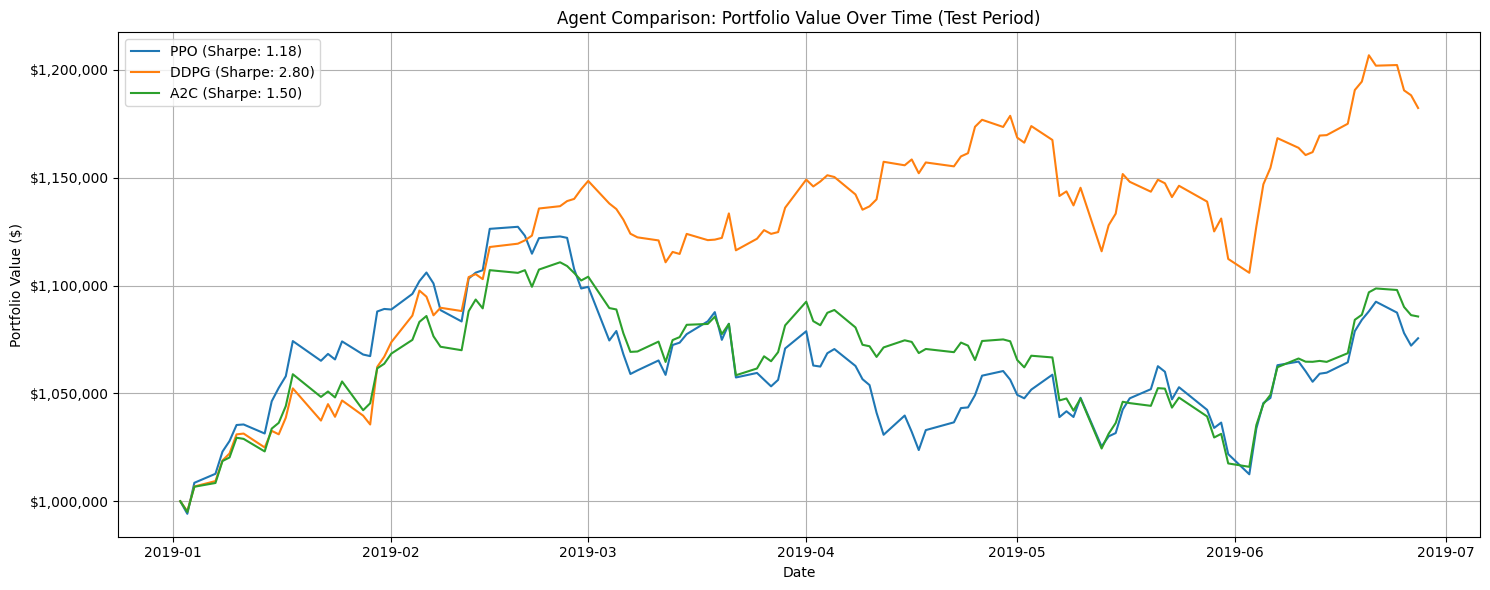

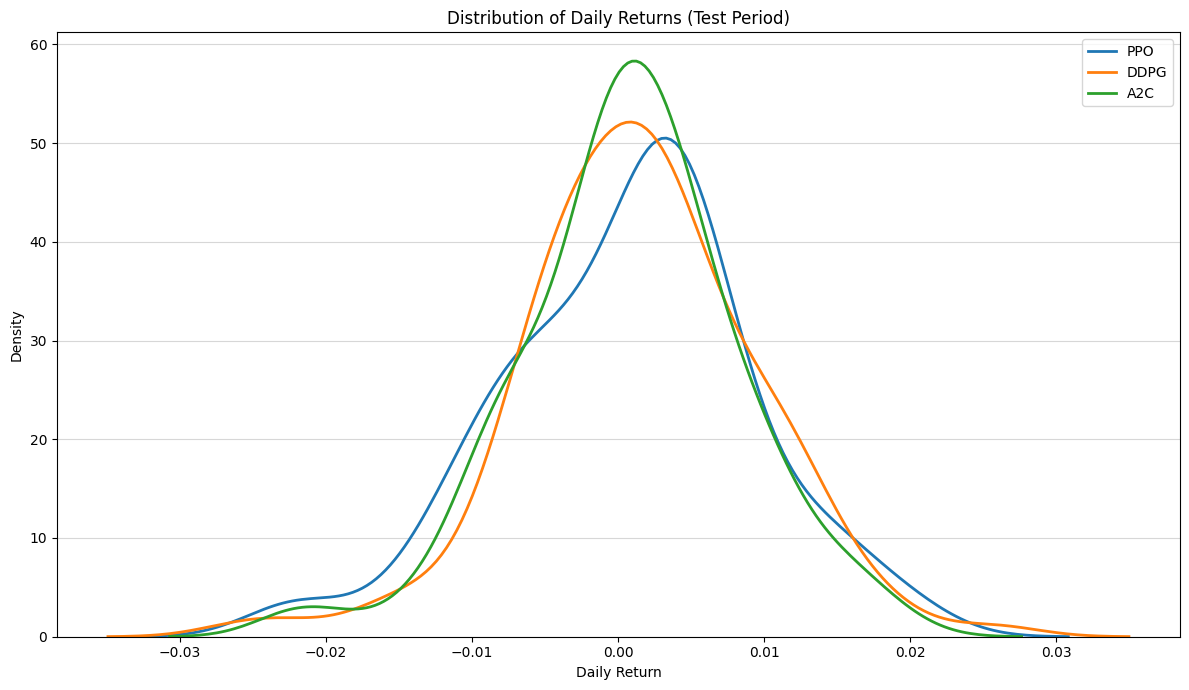

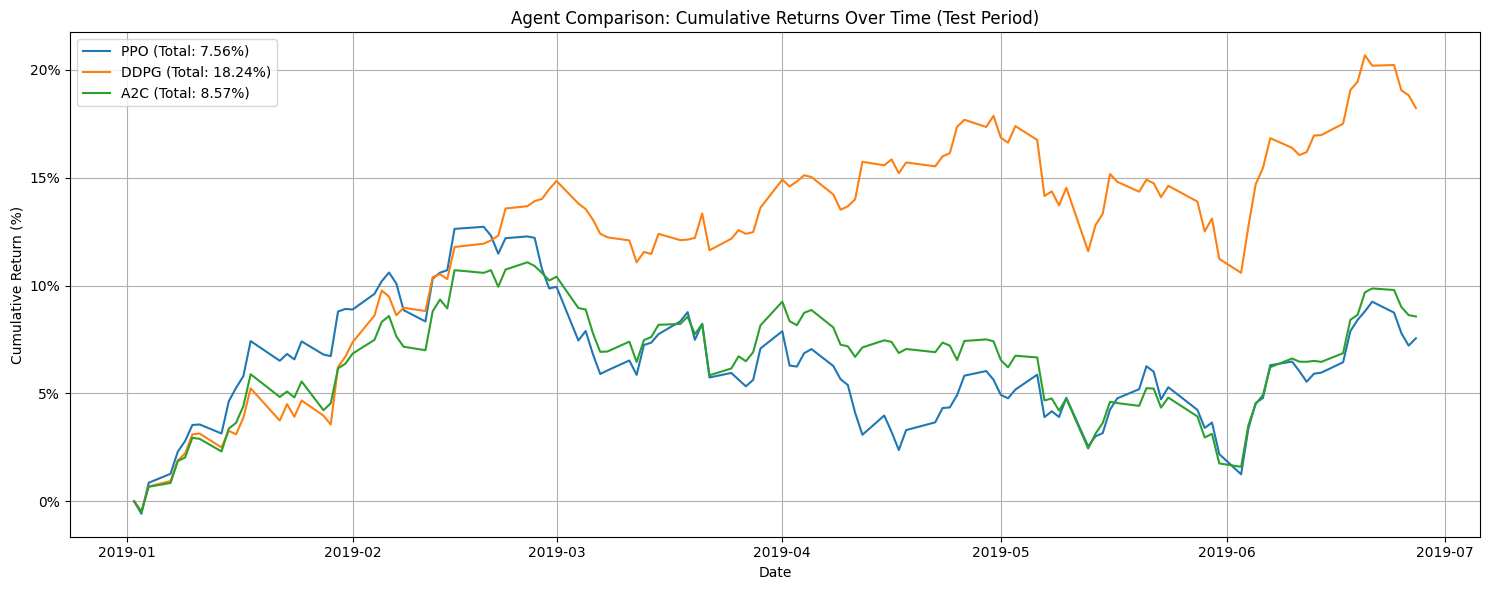

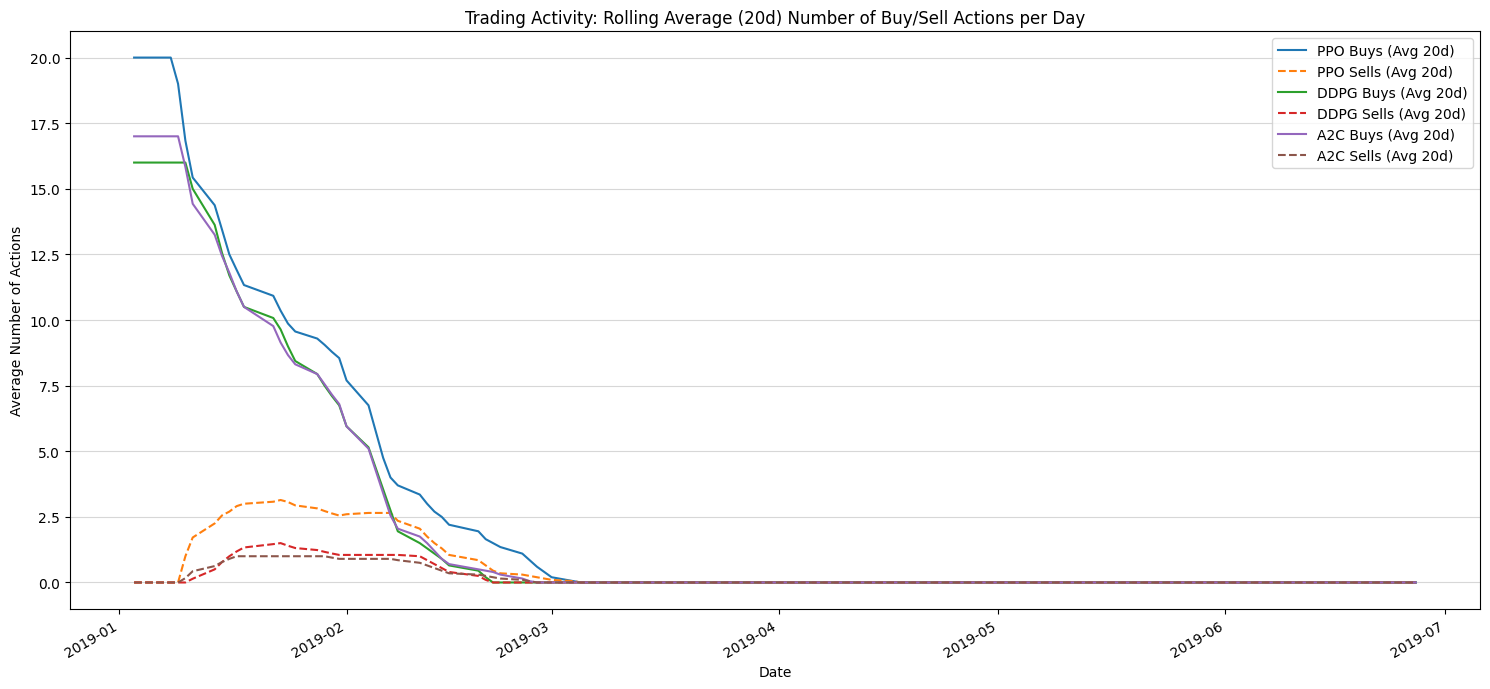

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # For potentially nicer plots like KDE
import os
import torch # Needed for agent definition/loading

# Ensure matplotlib plots appear inline in notebooks
%matplotlib inline

# Import your agent classes (adjust paths if they are in separate files)
# ... (Make sure Agent classes are defined or imported here) ...

# --- Load Test Data ---
try:
    # Use the correct CSV file name if different
    test_df = pd.read_csv("trade_with_sentiment.csv", index_col=0)
    # Optional: Ensure index is datetime if needed
    # test_df.index = pd.to_datetime(test_df.index)
    print(f"Test data loaded successfully. Columns: {test_df.columns.tolist()}")
except FileNotFoundError:
    print("Error: test data file 'trade_with_sentiment.csv' not found.")
    test_df = None # Set to None to prevent further execution

# --- Environment Parameters (UPDATED based on your columns) ---
if test_df is not None:
    stock_dim = len(test_df.tic.unique()) # Infer from test data

    # *** MODIFICATION START ***
    # Use only the indicators present in your final data
    tech_indicators = ['macd', 'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30',
                   'close_30_sma', 'close_60_sma', 'vix', 'turbulence', 'sentiment_2w']

    # Filter list to only include columns actually in test_df
    tech_indicators = [indicator for indicator in tech_indicators if indicator in test_df.columns]
    print(f"Using Technical Indicators: {tech_indicators}")

    # Recalculate state_space based on the actual indicators being used
    # State: [Cash Balance] + [Prices]*stock_dim + [Shares]*stock_dim + [Indicators]*stock_dim
    state_space = 1 + 2*stock_dim + len(tech_indicators)*stock_dim
    # *** MODIFICATION END ***

    action_space = stock_dim
    hmax = 100
    initial_amount = 1_000_000
    # Use list comprehensions for costs if applying to all stocks
    buy_cost_pct = [0.001] * stock_dim
    sell_cost_pct = [0.001] * stock_dim
    reward_scaling = 1e-4

    # Agent architecture (Must match saved models)
    ppo_hidden_sizes = (64, 64)  # Example, use your actuals
    ddpg_hidden_sizes = (128, 128) # Example, use your actuals
    a2c_hidden_sizes = (64, 64)  # Example, use your actuals

    # Device
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Saved model paths (Ensure these are correct)
    ppo_model_path = "ppo_from_scratch.pth"
    ddpg_model_dir = "./ddpg_scratch_model"
    a2c_model_path = "a2c_from_scratch.pth"

    print(f"Stock Dimension: {stock_dim}")
    print(f"State Space: {state_space}") # Verify this number matches training!

    # --- 1) Rebuild the Test Environment ---
    # Use the same environment setup for all agents for fair comparison
    from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

    test_env = StockTradingEnv(
        df=test_df,
        stock_dim=stock_dim,
        hmax=hmax,
        initial_amount=initial_amount,
        num_stock_shares=[0]*stock_dim,
        buy_cost_pct=buy_cost_pct, # Pass the list
        sell_cost_pct=sell_cost_pct,# Pass the list
        reward_scaling=reward_scaling,
        state_space=state_space, # Use recalculated state_space
        action_space=action_space,
        tech_indicator_list=tech_indicators, # Use updated list
        print_verbosity=1000,
        turbulence_threshold=None, # Make sure turbulence column exists if threshold is used
        risk_indicator_col="turbulence" # FinRL uses this internally if threshold is set
    )

    # --- (The rest of the testing code remains the same) ---

    # Dictionary to store results
    results = {}

    # --- 2) Test Each Agent ---
# --- 2) Test Each Agent ---

    agent_configs = {
        # Assuming PPO and A2C might now require explicit dims based on the error
        "PPO": {"class": PPOAgent, "path": ppo_model_path, "hidden": ppo_hidden_sizes, "dir": False, "needs_dims": True},
        "DDPG": {"class": DDPGAgent, "path": ddpg_model_dir, "hidden": ddpg_hidden_sizes, "dir": True, "needs_dims": False},
        "A2C": {"class": A2CAgent, "path": a2c_model_path, "hidden": a2c_hidden_sizes, "dir": False, "needs_dims": False}, # Check A2C's __init__
    }

    # Make sure these dimensions are defined from the setup block above
    current_state_dim = state_space
    current_action_dim = action_space

    for name, config in agent_configs.items():
        print(f"\n--- Testing {name} Agent ---")
        # Instantiate agent structure
        try:
            # ---> MODIFICATION START <---
            if config["needs_dims"]:
                 # Pass state_dim and action_dim explicitly if required
                 agent = config["class"](
                     state_dim=current_state_dim,
                     action_dim=current_action_dim,
                     env=test_env, # Pass env too, might be needed for action bounds etc.
                     hidden_sizes=config["hidden"],
                     device=device
                     # Add other necessary non-training args from __init__ if needed
                 )
            else:
                 # Instantiate without explicit dims (e.g., for DDPG as defined earlier)
                 agent = config["class"](
                     env=test_env,
                     hidden_sizes=config["hidden"],
                     device=device
                 )
            # ---> MODIFICATION END <---

        except TypeError as e:
             print(f"TypeError during {name} instantiation: {e}")
             print(f"Please check the __init__ signature of your {name} class matches the arguments being passed.")
             continue # Skip testing this agent if instantiation fails
        except Exception as e:
            print(f"An unexpected error occurred during {name} instantiation: {e}")
            continue


        # Load weights
        try:
            if config["dir"]: # DDPG loads from directory
                agent.load(config["path"])
            else: # PPO/A2C load from file
                 agent.load(config["path"])
        except FileNotFoundError:
            print(f"Error: Model weights not found for {name} at {config['path']}")
            continue # Skip testing this agent
        except Exception as e:
             print(f"An unexpected error occurred during {name} model loading: {e}")
             continue

        # Run deterministic test rollout
        # ... (rest of the rollout loop remains the same) ...

        # --- (Rollout loop code as before) ---
        test_env.reset() # Reset env for each agent!
        out = test_env.state # Access state after reset
        state = out[0] if isinstance(out, tuple) else out
        state = np.asarray(state, dtype=np.float32) # Ensure correct type

        done = False
        while not done:
            try:
                action = agent.predict(state) # Use deterministic prediction
                step = test_env.step(action)

                if len(step) == 5:
                    obs, reward, term, trunc, info = step
                    done = bool(term or trunc)
                else:
                    obs, reward, done, info = step

                state = obs if not isinstance(obs, tuple) else obs[0]
                state = np.asarray(state, dtype=np.float32) # Ensure correct type
            except Exception as e:
                print(f"Error during {name} rollout step: {e}")
                done = True # Stop rollout for this agent on error

        # --- (Result extraction and calculation code as before) ---
        # Extract test results (only if rollout completed somewhat)
        if test_env.day > 0: # Check if at least one step was taken
            print(f"{name} rollout complete (or stopped due to error).")
            dates = pd.to_datetime(test_env.date_memory)
            assets = np.array(test_env.asset_memory)
            actions_df = test_env.save_action_memory() # Get actions DataFrame

            if len(assets) > 1:
                daily_rets = assets[1:] / assets[:-1] - 1
                total_return = assets[-1] / assets[0] - 1
                sharpe_ratio = (daily_rets.mean() / (daily_rets.std()+1e-8)) * np.sqrt(252) # Annualized Sharpe

                results[name] = {
                    "dates": dates,
                    "assets": assets,
                    "actions": actions_df,
                    "daily_returns": daily_rets,
                    "total_return": total_return,
                    "sharpe_ratio": sharpe_ratio
                }
                print(f"  Test: {dates[0].date()} -> {dates[-1].date()} | "
                      f"Final=${assets[-1]:,.2f} | Return={total_return*100:.2f}% | Sharpe={sharpe_ratio:.2f}")
            else:
                 print(f"  Warning: Not enough data points in asset memory for {name} to calculate metrics.")
        else:
            print(f"  {name} rollout did not complete enough steps for analysis.")


    # --- (Plotting code remains the same) ---
    # ...
    # --- 3) Comparison Plot (Portfolio Value) ---

    if results: # Check if any results were generated
        plt.figure(figsize=(15, 6))
        for name, data in results.items():
            plt.plot(data["dates"], data["assets"], label=f"{name} (Sharpe: {data['sharpe_ratio']:.2f})")

        plt.title("Agent Comparison: Portfolio Value Over Time (Test Period)")
        plt.xlabel("Date")
        plt.ylabel("Portfolio Value ($)")
        plt.legend()
        plt.grid(True)
        # Optional: Format y-axis as currency
        try:
            from matplotlib.ticker import FuncFormatter
            plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x:,.0f}"))
        except ImportError:
            print("Note: Optional currency formatting requires matplotlib.ticker")
        plt.tight_layout()
        plt.show()

        # --- 4) Additional Relevant Plots ---

        # Plot 1: Daily Returns Distribution (Histogram or KDE)
        plt.figure(figsize=(12, 7))
        for name, data in results.items():
            sns.kdeplot(data["daily_returns"], label=f"{name}", lw=2)
            # Or use histogram:
            # plt.hist(data["daily_returns"], bins=50, alpha=0.6, label=f"{name}")

        plt.title("Distribution of Daily Returns (Test Period)")
        plt.xlabel("Daily Return")
        plt.ylabel("Density") # Or "Frequency" if using hist
        plt.legend()
        plt.grid(True, axis='y', alpha=0.5)
        plt.tight_layout()
        plt.show()

        # Plot 2: Cumulative Returns
        plt.figure(figsize=(15, 6))
        for name, data in results.items():
            cumulative_returns = (data["assets"] / data["assets"][0]) - 1
            plt.plot(data["dates"], cumulative_returns * 100, label=f"{name} (Total: {data['total_return']*100:.2f}%)")

        plt.title("Agent Comparison: Cumulative Returns Over Time (Test Period)")
        plt.xlabel("Date")
        plt.ylabel("Cumulative Return (%)")
        plt.legend()
        plt.grid(True)
        # Format y-axis as percentage
        try:
            from matplotlib.ticker import FuncFormatter
            plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))
        except ImportError:
             print("Note: Optional percentage formatting requires matplotlib.ticker")

        plt.tight_layout()
        plt.show()


        # Plot 3: Trading Activity (Buy/Sell/Hold Count per Day)
        # This requires processing the actions_df for each agent
        # Plot 3: Trading Activity (Buy/Sell/Hold Count per Day)
        plt.figure(figsize=(15, 7))
        n_agents = len(results)
        # bar_width = 0.8 / n_agents # Not needed for line plot

        for i, (name, data) in enumerate(results.items()):
            # Check if required data exists
            if "actions" not in data or data["actions"].empty or \
               "dates" not in data or len(data["dates"]) < 2:
                print(f"Skipping trading activity plot for {name}: Missing or insufficient action/date data.")
                continue

            actions = data["actions"].copy() # Work on a copy
            buy_threshold = 0.01
            sell_threshold = -0.01

            # Count actions per step (date) - sum across stocks
            # This Series should have length T (e.g., 122)
            daily_buys = (actions > buy_threshold).sum(axis=1)
            daily_sells = (actions < sell_threshold).sum(axis=1)
            # daily_holds = action_space - buys - sells # Not plotted

            # --- FIX: Align Dates and Actions ---
            # date_memory has T+1 dates, action data has T steps.
            # Use dates starting from the second day to match the action steps.
            if len(data["dates"]) == len(daily_buys) + 1:
                dates_for_plot = data["dates"][1:] # Shape should now be (T,) e.g., (122,)
            elif len(data["dates"]) == len(daily_buys):
                # If somehow lengths already match
                print(f"Note: Dates and actions length match unexpectedly for {name}. Using all dates.")
                dates_for_plot = data["dates"]
            else:
                print(f"Warning: Cannot align dates (len {len(data['dates'])}) and daily actions (len {len(daily_buys)}) for {name}. Skipping activity plot.")
                continue
            # --- End Fix ---


            # Alternative: Line plot of rolling average activity
            rolling_window = 20 # e.g., 20 trading days

            # Check if enough data for the rolling window
            if len(daily_buys) >= rolling_window:
                # Use min_periods=1 to avoid NaNs at the beginning just due to window size
                # The rolling Series will still have length T (e.g., 122)
                rolling_buys_mean = daily_buys.rolling(rolling_window, min_periods=1).mean()
                rolling_sells_mean = daily_sells.rolling(rolling_window, min_periods=1).mean()

                # Plot using the aligned dates_for_plot (length T) and rolling means (length T)
                plt.plot(dates_for_plot, rolling_buys_mean, label=f'{name} Buys (Avg {rolling_window}d)', linestyle='-')
                plt.plot(dates_for_plot, rolling_sells_mean, label=f'{name} Sells (Avg {rolling_window}d)', linestyle='--')
            elif len(daily_buys) > 0 : # Plot raw if not enough for rolling
                print(f"Warning: Not enough data points ({len(daily_buys)}) for rolling window ({rolling_window}) for {name}. Plotting raw counts.")
                plt.plot(dates_for_plot, daily_buys, label=f'{name} Buys (Raw)', linestyle='-')
                plt.plot(dates_for_plot, daily_sells, label=f'{name} Sells (Raw)', linestyle='--')
            else:
                print(f"Skipping activity plot for {name}: No daily action data.")


        # Configure plot appearance (only if anything was plotted)
        # Check if the axes actually contain any lines before setting labels/titles
        if plt.gca().has_data():
            plt.title(f"Trading Activity: Rolling Average ({rolling_window}d) Number of Buy/Sell Actions per Day")
            plt.xlabel("Date")
            plt.ylabel("Average Number of Actions")
            plt.legend(loc='best') # Let matplotlib decide best location
            plt.grid(True, axis='y', alpha=0.5)
            try:
                 plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
                 plt.gcf().autofmt_xdate() # Rotate dates
            except Exception:
                pass # Ignore formatting errors if they occur
            plt.tight_layout()
            plt.show()
        else:
             plt.close() # Close the empty figure if nothing was plotted
             print("Activity plot skipped as no agents had sufficient data.")

In [58]:
test_df.columns

Index(['date', 'tic', 'close', 'high', 'low', 'open', 'volume', 'day', 'macd',
       'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma',
       'close_60_sma', 'vix', 'turbulence', 'sentiment_2w'],
      dtype='object')

In [66]:
# reinforce_scratch.py
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import time

# --- Policy Network Only ---
# (Can reuse ActorCritic's structure but only need the policy part)
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_sizes=(64,64)):
        super().__init__()
        layers = []
        last_dim = state_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last_dim, h), nn.ReLU()]
            last_dim = h
        self.shared = nn.Sequential(*layers)
        self.mean = nn.Linear(last_dim, action_dim)
        # Learn log standard deviation
        self.log_std = nn.Parameter(torch.zeros(action_dim)) # Starts near std=1

    def forward(self, x):
        x = self.shared(x)
        mean_out = self.mean(x)

        # Clamp log_std for stability
        log_std_clamped = torch.clamp(self.log_std, -20, 2)
        std_out = torch.exp(log_std_clamped)

        # Ensure finite outputs
        if not torch.all(torch.isfinite(mean_out)):
            print("Warning: Non-finite values detected in policy mean output. Clamping.")
            mean_out = torch.nan_to_num(mean_out, nan=0.0, posinf=1.0, neginf=-1.0)
        if not torch.all(torch.isfinite(std_out)) or torch.any(std_out <= 0):
             print(f"Warning: Non-finite or non-positive std detected: {std_out}. Using default.")
             # Ensure std_out has same shape as mean_out if mean_out is batched
             std_out = torch.ones_like(mean_out) * 0.1 # Fallback std

        return mean_out, std_out

# --- REINFORCE Agent ---
class REINFORCEAgent:
    def __init__(
        self,
        state_dim, # Explicitly required
        action_dim,# Explicitly required
        env, # Still needed for action bounds
        gamma=0.99,
        lr=1e-3, # REINFORCE often needs careful LR tuning, try higher/lower
        hidden_sizes=(64, 64),
        log_interval=10, # Log every 10 episodes maybe
        device=None
    ):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.env = env # Keep env reference for bounds
        self.gamma = gamma
        self.lr = lr
        self.log_interval = log_interval
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        print(f"REINFORCE using device: {self.device}")
        print(f"  State Dim: {self.state_dim}, Action Dim: {self.action_dim}")


        # Action bounds for clamping
        if hasattr(env.action_space, 'low') and hasattr(env.action_space, 'high'):
            self.act_low = torch.tensor(env.action_space.low, dtype=torch.float32).to(self.device)
            self.act_high = torch.tensor(env.action_space.high, dtype=torch.float32).to(self.device)
            print(f"  Inferring bounds from env.action_space: {env.action_space}")
        else:
            print("Warning: env.action_space doesn't have low/high bounds. Assuming [-1, 1].")
            self.act_low = torch.full((self.action_dim,), -1.0, dtype=torch.float32).to(self.device)
            self.act_high = torch.full((self.action_dim,), 1.0, dtype=torch.float32).to(self.device)

        # Network + optimizer
        self.policy = PolicyNetwork(self.state_dim, self.action_dim, hidden_sizes).to(self.device)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)

        # Experience buffer (stores data for one episode)
        self.reset_buffer()

        # Logging
        self.episode_rewards = []
        self.episode_lengths = []
        self.total_steps = 0

    def reset_buffer(self):
        # Stores log_probs and rewards for the current episode
        self.log_probs = []
        self.rewards = []

    def select_action(self, state):
        # state is numpy array
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device) # Add batch dim
        mean, std = self.policy(state_t)
        dist = Normal(mean, std)
        action = dist.sample() # Sample action

        # Calculate log probability - SUM across action dimensions
        log_prob = dist.log_prob(action).sum(dim=-1)

        # Store log_prob for the update step
        self.log_probs.append(log_prob)

        # Clamp action and return as numpy
        action_clamped = torch.clamp(action, self.act_low, self.act_high)
        return action_clamped.squeeze(0).detach().cpu().numpy() # Remove batch dim

    def predict(self, state):
        # For testing: use the deterministic mean of the policy
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
        with torch.no_grad():
            mean, _ = self.policy(state_t) # Ignore std dev for prediction
        action_clamped = torch.clamp(mean, self.act_low, self.act_high)
        return action_clamped.squeeze(0).cpu().numpy()

    def update(self):
        """ Calculates loss and updates policy based on the completed episode."""
        if not self.rewards or not self.log_probs:
            print("Warning: Update called with empty rewards or log_probs buffer.")
            return None # Cannot update without data

        T = len(self.rewards) # Number of steps in the episode
        discounted_returns = np.zeros(T, dtype=np.float32)
        running_return = 0.0

        # Calculate discounted returns G_t = sum_{k=t}^{T} gamma^(k-t) * R_k
        for t in reversed(range(T)):
            running_return = self.rewards[t] + self.gamma * running_return
            discounted_returns[t] = running_return

        # Convert to tensor
        returns = torch.tensor(discounted_returns).to(self.device)
        log_probs_t = torch.cat(self.log_probs) # Concatenate list of tensors

        # Normalize returns (VERY important for REINFORCE stability)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # Calculate policy loss: - E[log_prob * G_t] (or normalized G_t)
        # Ensure log_probs_t and returns have compatible shapes if needed
        policy_loss = -(log_probs_t * returns).mean() # Average over the episode steps

        # --- Optimize ---
        self.optimizer.zero_grad()
        policy_loss.backward()
        # Optional: Gradient clipping
        # torch.nn.utils.clip_grad_norm_(self.policy.parameters(), max_norm=1.0)
        self.optimizer.step()

        # Clear buffers for the next episode
        self.reset_buffer()

        return policy_loss.item()


    def learn(self, total_timesteps, verbose=False):
        """ Main REINFORCE training loop (episode-based). """

        self.total_steps = 0
        episode_count = 0
        start_time = time.time()

        while self.total_steps < total_timesteps:
            episode_count += 1
            # Reset env and buffer for the new episode
            reset_output = self.env.reset()
            state = reset_output[0] if isinstance(reset_output, tuple) else reset_output
            state = np.asarray(state, dtype=np.float32)
            self.reset_buffer() # Clear rewards and log_probs

            episode_reward = 0
            episode_length = 0
            done = False

            # --- Run one episode ---
            while not done:
                # select_action samples, clamps, and stores log_prob
                action_np = self.select_action(state)

                step_out = self.env.step(action_np)
                if len(step_out) == 5: # Gymnasium API
                    obs, reward, terminated, truncated, _ = step_out
                    done = bool(terminated or truncated)
                else: # Older Gym API
                    obs, reward, done, _ = step_out

                next_state = np.asarray(obs, dtype=np.float32)
                reward = float(reward)

                # Store reward for this step
                self.rewards.append(reward)

                state = next_state
                episode_reward += reward
                episode_length += 1
                self.total_steps += 1

                if self.total_steps >= total_timesteps:
                     print("Total timesteps reached during episode.")
                     break # Exit inner loop if total timesteps met

            # --- Episode finished: Update policy ---
            loss = self.update() # Uses self.rewards and self.log_probs

            # Logging
            self.episode_rewards.append(episode_reward)
            self.episode_lengths.append(episode_length)

            if verbose and episode_count % self.log_interval == 0:
                avg_reward = np.mean(self.episode_rewards[-self.log_interval:])
                avg_length = np.mean(self.episode_lengths[-self.log_interval:])
                print(f"Episode: {episode_count} | Timestep: {self.total_steps}/{total_timesteps} | "
                      f"Avg Reward (Last {self.log_interval}): {avg_reward:.2f} | Avg Length: {avg_length:.1f} | "
                      f"Last Loss: {loss if loss is not None else 'N/A':.4f}")

            if self.total_steps >= total_timesteps:
                 break # Exit outer loop


        end_time = time.time()
        print("\n==========================================")
        print("Training complete.")
        print(f"Total Timesteps: {self.total_steps}")
        print(f"Total Episodes: {episode_count}")
        print(f"Training Time: {end_time - start_time:.2f} seconds")
        print("==========================================")


    def save(self, path):
        """ Saves the Policy network weights."""
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        print(f"Saving REINFORCE policy network to {path}")
        torch.save(self.policy.state_dict(), path)

    def load(self, path):
        """ Loads the Policy network weights."""
        print(f"Loading REINFORCE policy network from {path}")
        # Ensure network exists before loading state dict
        if not hasattr(self, 'policy'):
             # Need to know hidden_sizes used by saved model! Assume stored or passed.
             hs = self.policy.shared[0].out_features, self.policy.shared[2].out_features # Try to infer
             self.policy = PolicyNetwork(self.state_dim, self.action_dim, hs).to(self.device)

        self.policy.load_state_dict(torch.load(path, map_location=self.device))
        self.policy.eval() # Set to evaluation mode
        print("REINFORCE model loaded and set to eval mode.")

In [68]:
# --- REINFORCE Training ---

# Assuming 'train' DataFrame, 'stock_dim', 'state_space'=378, 'action_space',
# 'tech_indicators' (matching training, e.g., the 11 indicators for state_space=378)
# are defined correctly.

from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
# from reinforce_scratch import REINFORCEAgent # If saved in a separate file

# 1) Build FinRL env (MUST match state_space=378)
reinforce_train_env = StockTradingEnv(
    df=train,
    stock_dim=stock_dim,
    hmax=hmax,
    initial_amount=initial_amount,
    num_stock_shares=[0]*stock_dim,
    buy_cost_pct=buy_cost_pct,
    sell_cost_pct=sell_cost_pct,
    reward_scaling=reward_scaling, # REINFORCE can be sensitive to reward scale
    state_space=state_space,      # Should be 378
    action_space=action_space,
    tech_indicator_list=tech_indicators, # List resulting in state_space=378
    print_verbosity=1000,
    turbulence_threshold=None,
    risk_indicator_col="turbulence"
)
print(f"REINFORCE Training Env State Space: {reinforce_train_env.state_space}") # Verify 378

# 2) Instantiate REINFORCE Agent
# **Requires explicit state_dim and action_dim**
reinforce_agent = REINFORCEAgent(
    state_dim=reinforce_train_env.state_space, # Pass state_space (378)
    action_dim=reinforce_train_env.action_space.shape[0], # Pass action dim (29)
    env=reinforce_train_env, # Still pass env for action bounds
    gamma=0.99,
    lr=5e-4, # Learning rate might need significant tuning
    hidden_sizes=(64, 64), # Match PPO/A2C size
    log_interval=10, # Log every 10 episodes
    device=device
)

# 3) Train
print("Starting REINFORCE Training...")
# REINFORCE is sample inefficient, might need more steps than A2C/PPO
# But training time per step is less (no critic update)
reinforce_agent.learn(total_timesteps=100000, verbose=True) # Adjust as needed

# 4) Save weights
reinforce_agent.save("reinforce_from_scratch.pth")

print("\nREINFORCE Training Finished.")
# Optional: Plot training rewards
# plt.figure(figsize=(12, 5))
# plt.plot(reinforce_agent.episode_rewards)
# plt.plot(pd.Series(reinforce_agent.episode_rewards).rolling(10).mean()) # Rolling avg
# plt.title("REINFORCE Training Episode Rewards")
# plt.xlabel("Episode")
# plt.ylabel("Total Reward")
# plt.show()

REINFORCE Training Env State Space: 378
REINFORCE using device: cpu
  State Dim: 378, Action Dim: 29
  Inferring bounds from env.action_space: Box(-1.0, 1.0, (29,), float32)
Starting REINFORCE Training...
Episode: 10 | Timestep: 7540/100000 | Avg Reward (Last 10): 44.12 | Avg Length: 754.0 | Last Loss: 0.0228
Episode: 20 | Timestep: 15080/100000 | Avg Reward (Last 10): 51.02 | Avg Length: 754.0 | Last Loss: -0.0484
Episode: 30 | Timestep: 22620/100000 | Avg Reward (Last 10): 54.32 | Avg Length: 754.0 | Last Loss: -0.2291
Episode: 40 | Timestep: 30160/100000 | Avg Reward (Last 10): 58.90 | Avg Length: 754.0 | Last Loss: -0.0198
Episode: 50 | Timestep: 37700/100000 | Avg Reward (Last 10): 63.59 | Avg Length: 754.0 | Last Loss: 0.1691
Episode: 60 | Timestep: 45240/100000 | Avg Reward (Last 10): 65.33 | Avg Length: 754.0 | Last Loss: 0.2597
Episode: 70 | Timestep: 52780/100000 | Avg Reward (Last 10): 63.91 | Avg Length: 754.0 | Last Loss: 0.0086
Episode: 80 | Timestep: 60320/100000 | Avg R

In [69]:
# --- Testing Script Modifications ---

# ... (Imports, data loading, ensure state_space=378 setup) ...

# --- 1) Rebuild the Test Environment (Code as before) ---
# test_env = StockTradingEnv(...) # state_space=378

# --- 2) Test Each Agent ---

agent_configs = {
    "PPO": {"class": PPOAgent, "path": ppo_model_path, "hidden": ppo_hidden_sizes, "dir": False, "needs_dims": True},
    "DDPG": {"class": DDPGAgent, "path": ddpg_model_dir, "hidden": ddpg_hidden_sizes, "dir": True, "needs_dims": False},
    "A2C": {"class": A2CAgent, "path": a2c_model_path, "hidden": a2c_hidden_sizes, "dir": False, "needs_dims": False},
    # *** ADD REINFORCE CONFIG ***
    "REINFORCE": {"class": REINFORCEAgent, "path": "reinforce_from_scratch.pth", "hidden": (64, 64), "dir": False, "needs_dims": True} # REINFORCE needs dims
}

current_state_dim = state_space # Should be 378
current_action_dim = action_space
results = {}

# --- (Instantiate, Load, Rollout loop - check instantiation logic) ---
for name, config in agent_configs.items():
    print(f"\n--- Testing {name} Agent ---")
    try:
        if config["needs_dims"]:
             # PPO and REINFORCE need explicit dims
             agent = config["class"](
                 state_dim=current_state_dim,
                 action_dim=current_action_dim,
                 env=test_env, # Pass env for bounds etc.
                 hidden_sizes=config["hidden"],
                 device=device
             )
        else:
             # DDPG, A2C infer from env
             agent = config["class"](
                 env=test_env,
                 hidden_sizes=config["hidden"],
                 device=device
             )
        print(f"{name} agent instantiated.")

    except TypeError as e:
         print(f"TypeError during {name} instantiation: {e}")
         continue
    except Exception as e:
        print(f"An unexpected error occurred during {name} instantiation: {e}")
        continue

    # Load weights (should handle reinforce_from_scratch.pth)
    try:
        # ... (loading logic as before) ...
         if config["dir"]:
             agent.load(config["path"])
         else:
             agent.load(config["path"])
         print(f"{name} model loaded successfully.")
    except Exception as e:
         # ... (error handling as before) ...
         print(f"ERROR during {name} model loading: {e}")
         continue

    # --- Rollout loop (uses agent.predict - REINFORCE predict uses mean) ---
    # ... (rollout logic as before) ...

    # --- Result extraction (as before) ---
    # ... (store results in `results` dict) ...

# --- Plotting (Code as before - will automatically include REINFORCE) ---
# ... (Plots will now include REINFORCE results if testing was successful) ...


--- Testing PPO Agent ---
Using device: cpu
PPOAgent using state_dim=378, action_dim=29
  Inferring bounds from env.action_space: Box(-1.0, 1.0, (29,), float32)
PPO agent instantiated.
Loading model from ppo_from_scratch.pth
Model loaded and set to eval mode.
PPO model loaded successfully.

--- Testing DDPG Agent ---
Using device: cpu
Action bounds: Low=[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.], High=[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.]
Action scale: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.], Bias: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]
DDPG agent instantiated.
Loading models from ./ddpg_scratch_model
DDPG model loaded successfully.

--- Testing A2C Agent ---
Using device: cpu
A2C agent instantiated.
Loading model from a2c_from_scratch.pth
A2C model loaded suc


--- Testing PPO Agent ---
Using device: cpu
PPOAgent using state_dim=378, action_dim=29
  Inferring bounds from env.action_space: Box(-1.0, 1.0, (29,), float32)
PPO agent instantiated.
Loading model from ppo_from_scratch.pth
Model loaded and set to eval mode.
PPO model loaded successfully.
PPO rollout complete (or stopped due to error).
  Test: 2019-01-02 -> 2019-06-27 | Final=$1,075,586.59 | Return=7.56% | Sharpe=1.18


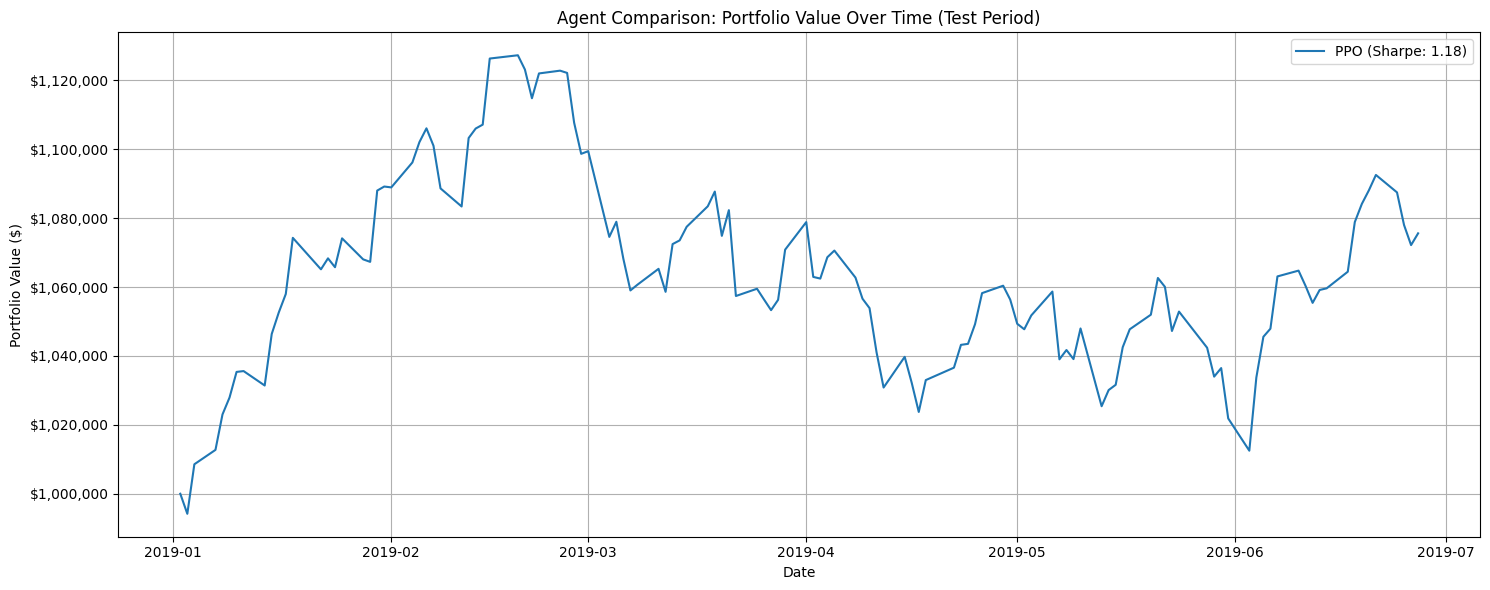

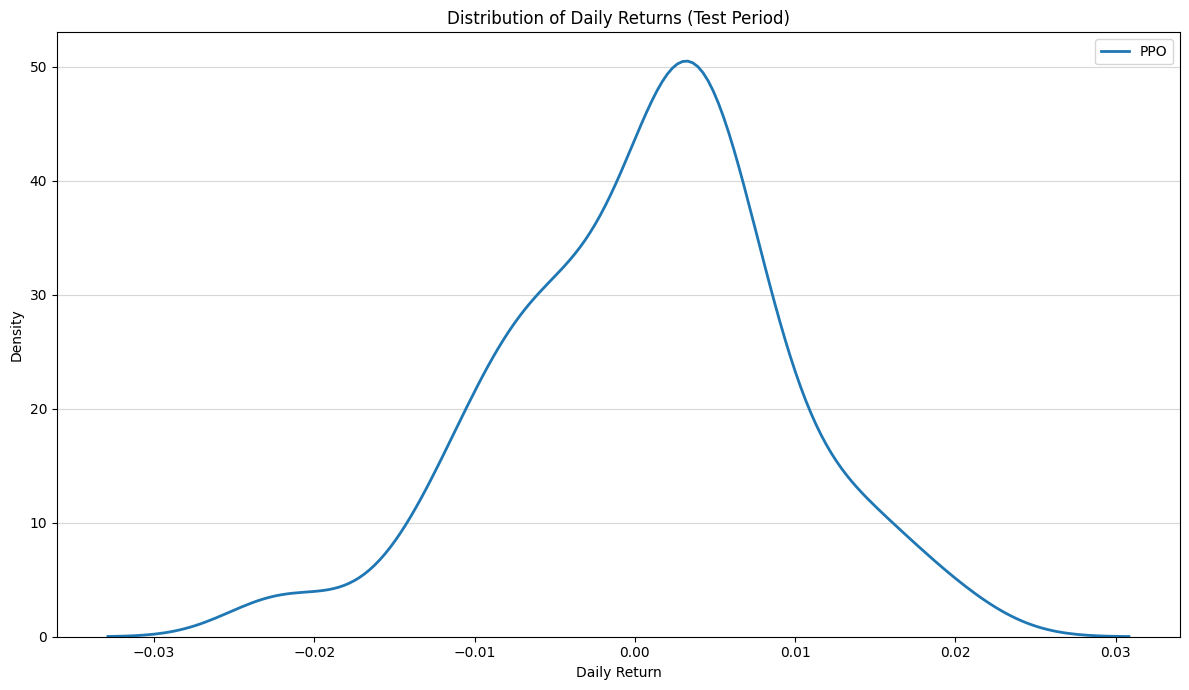

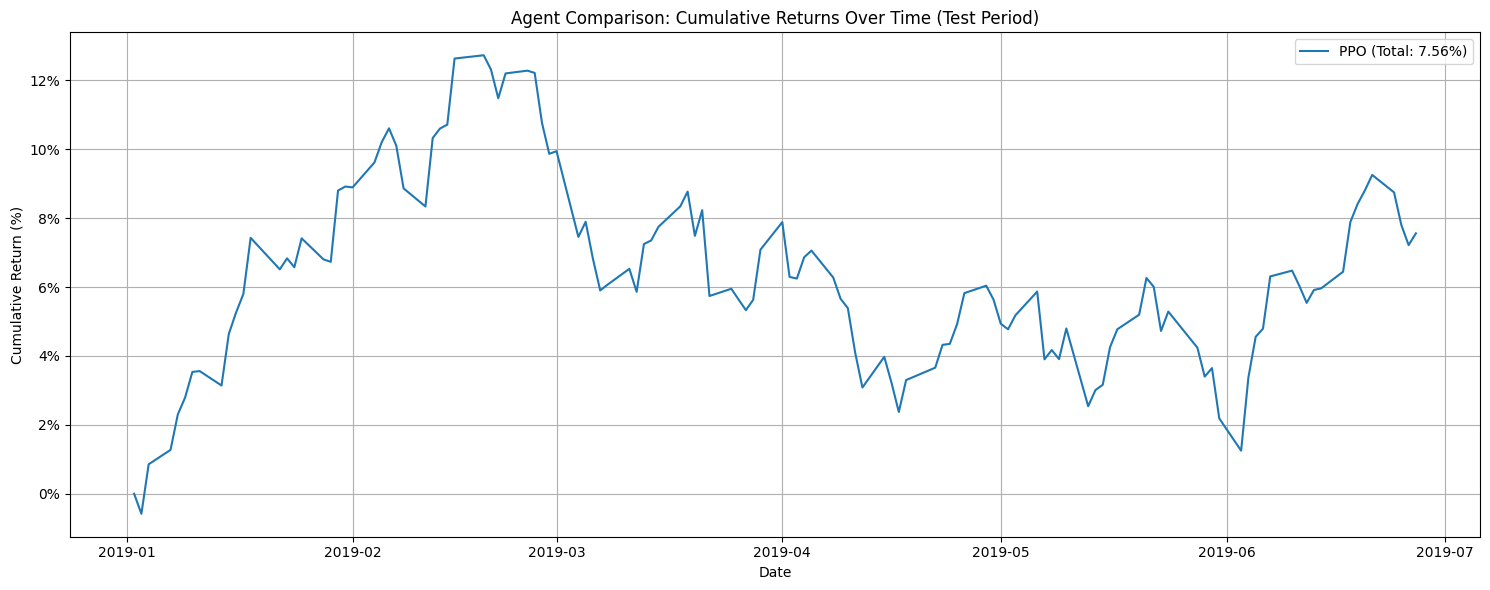

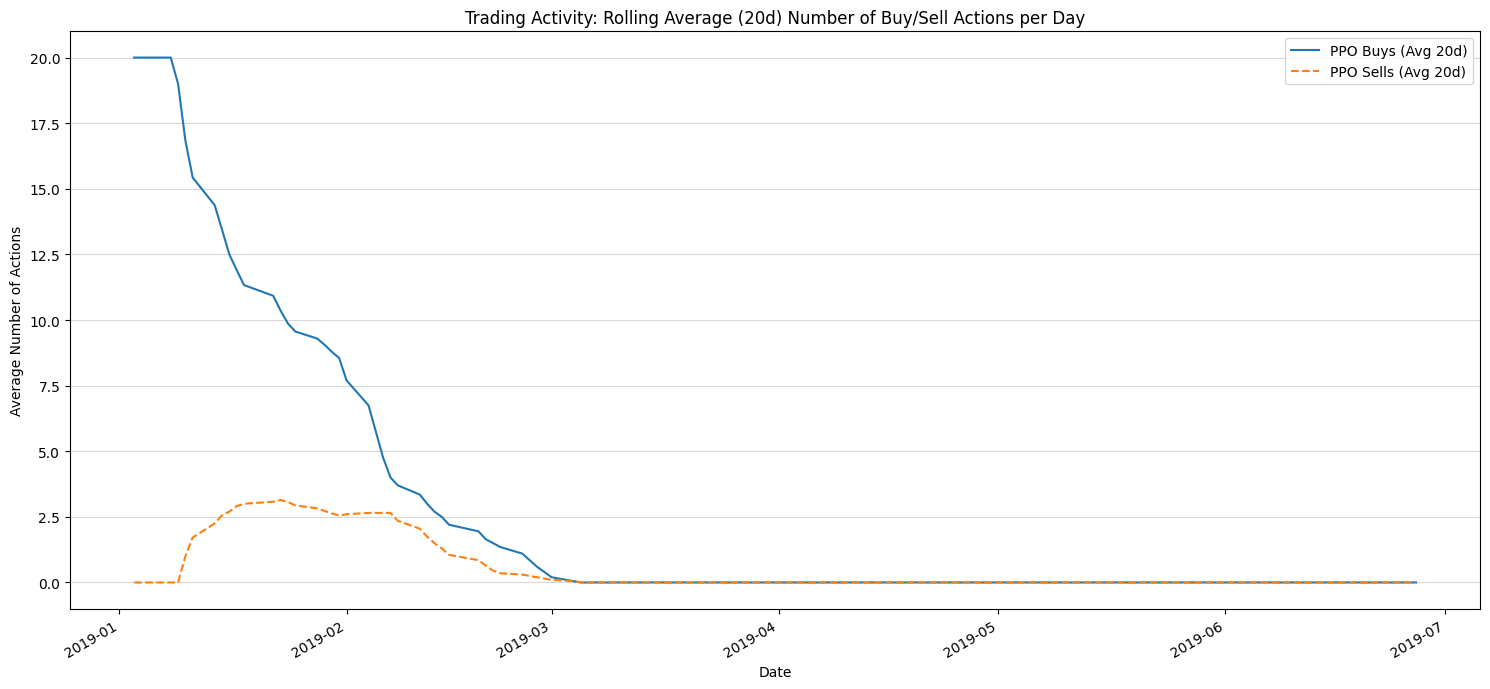


--- Testing DDPG Agent ---
Using device: cpu
Action bounds: Low=[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.], High=[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.]
Action scale: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.], Bias: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]
DDPG agent instantiated.
Loading models from ./ddpg_scratch_model
DDPG model loaded successfully.
DDPG rollout complete (or stopped due to error).
  Test: 2019-01-02 -> 2019-06-27 | Final=$1,182,369.33 | Return=18.24% | Sharpe=2.80


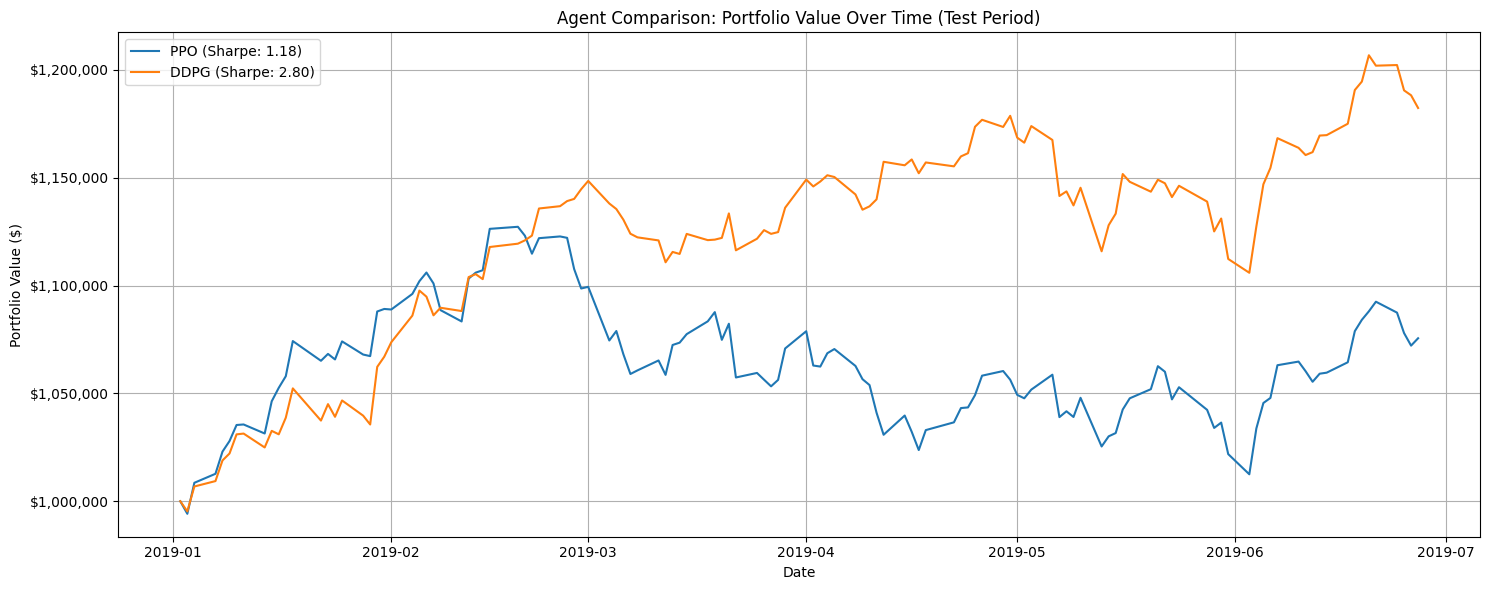

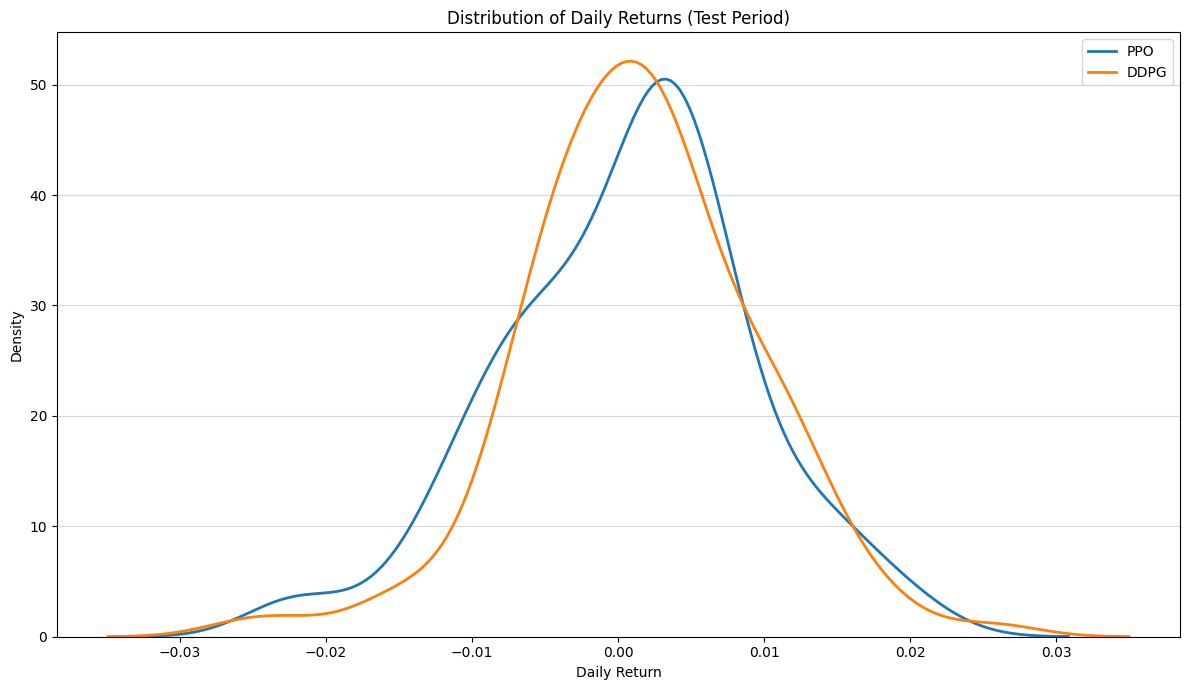

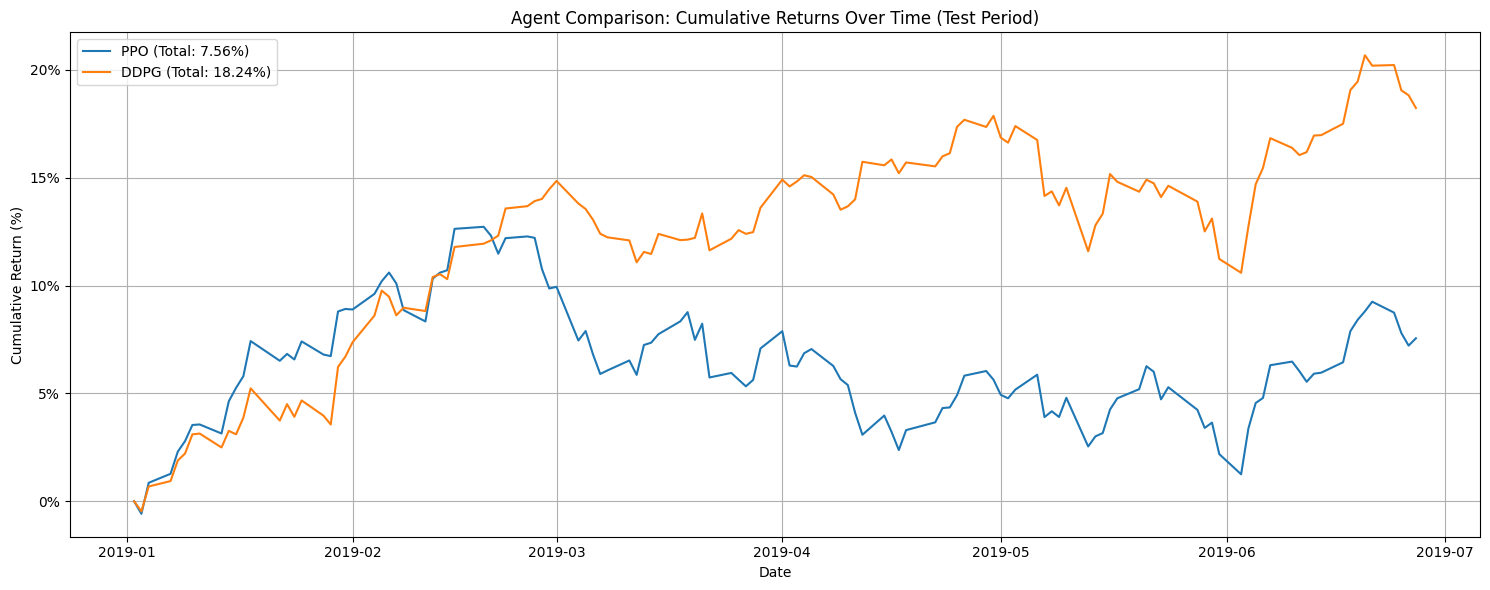

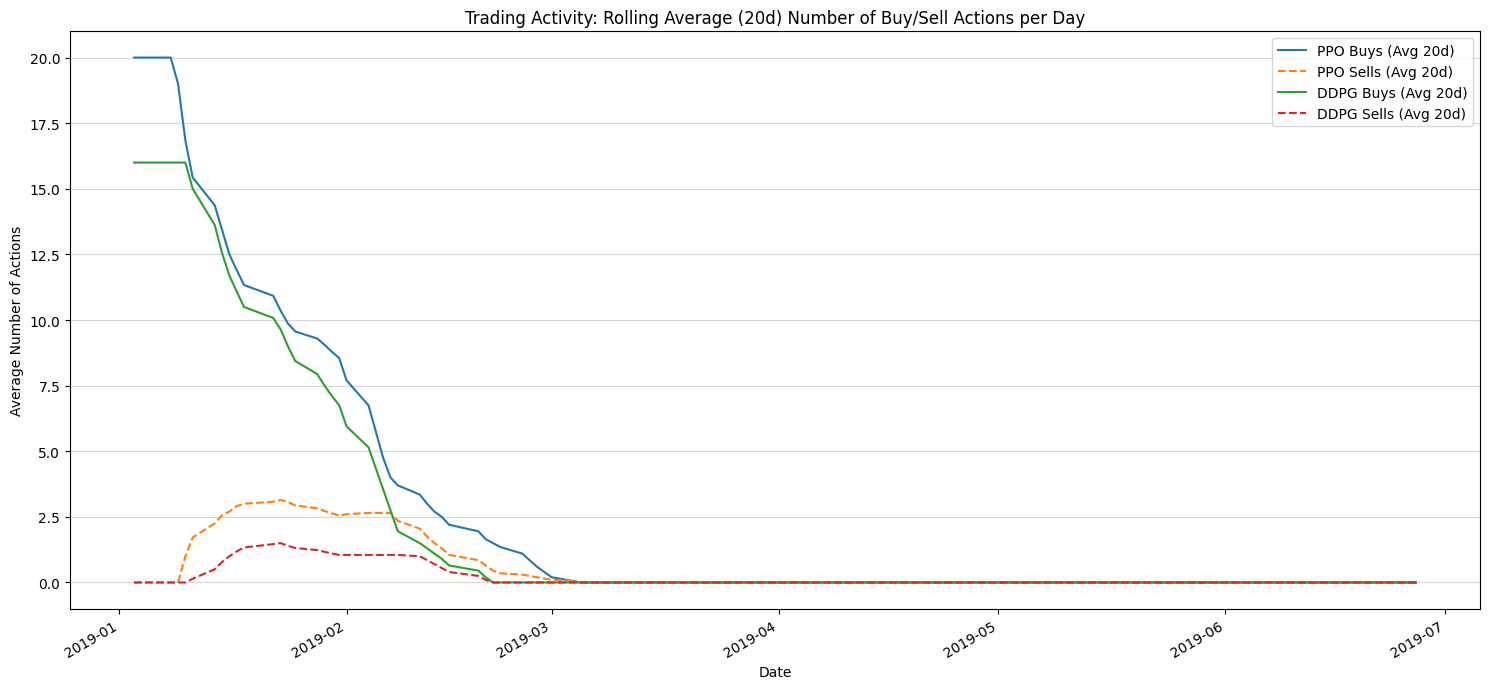


--- Testing A2C Agent ---
Using device: cpu
A2C agent instantiated.
Loading model from a2c_from_scratch.pth
A2C model loaded successfully.
A2C rollout complete (or stopped due to error).
  Test: 2019-01-02 -> 2019-06-27 | Final=$1,085,674.44 | Return=8.57% | Sharpe=1.50


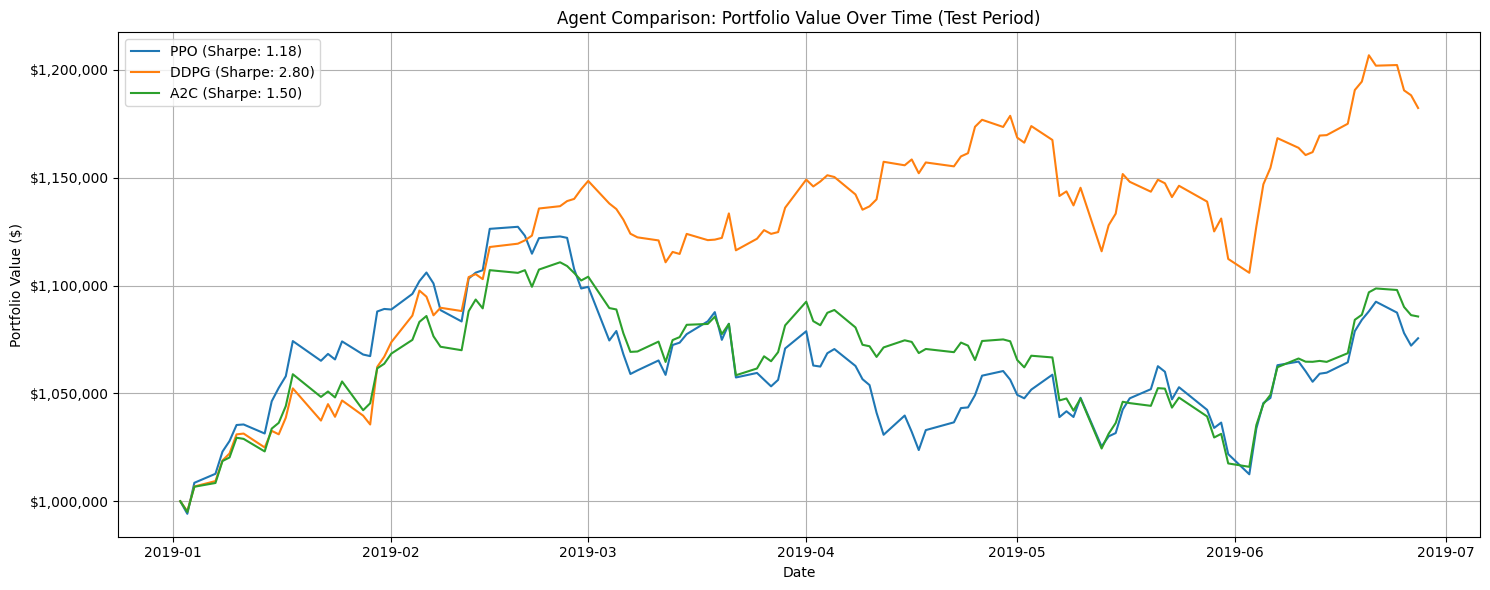

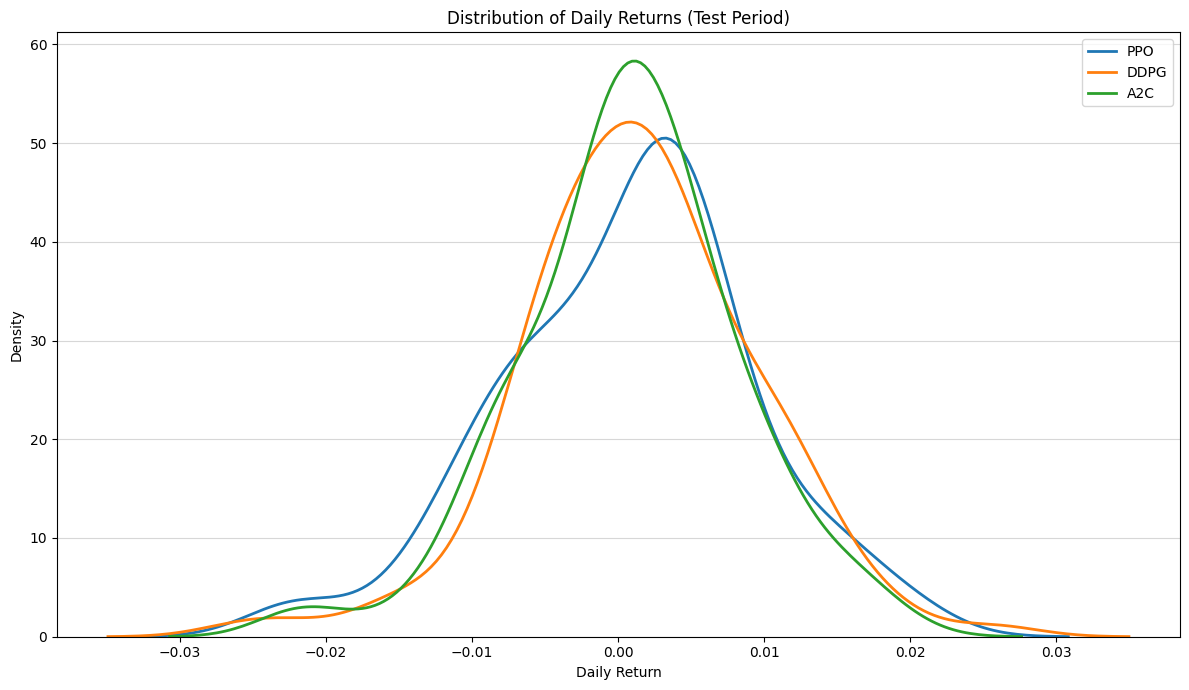

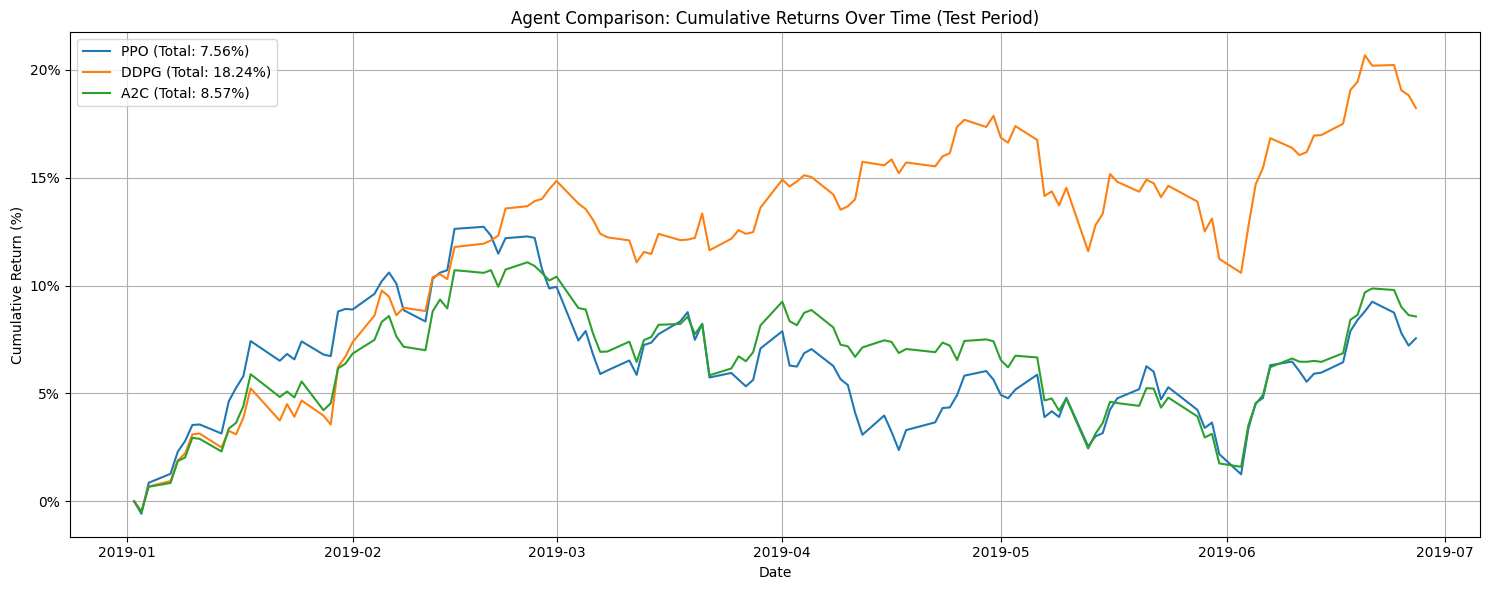

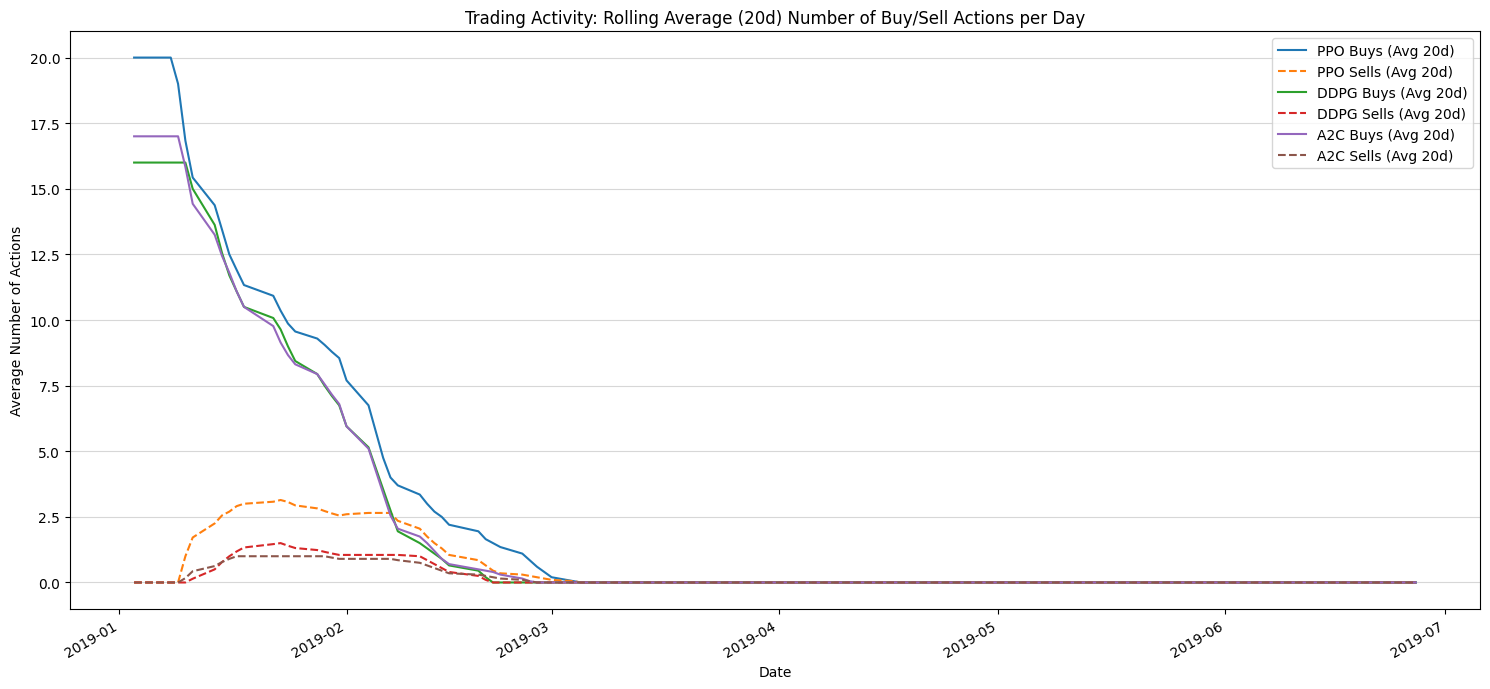


--- Testing REINFORCE Agent ---
REINFORCE using device: cpu
  State Dim: 378, Action Dim: 29
  Inferring bounds from env.action_space: Box(-1.0, 1.0, (29,), float32)
REINFORCE agent instantiated.
Loading REINFORCE policy network from reinforce_from_scratch.pth
REINFORCE model loaded and set to eval mode.
REINFORCE model loaded successfully.
REINFORCE rollout complete (or stopped due to error).
  Test: 2019-01-02 -> 2019-06-27 | Final=$1,090,015.94 | Return=9.00% | Sharpe=1.49


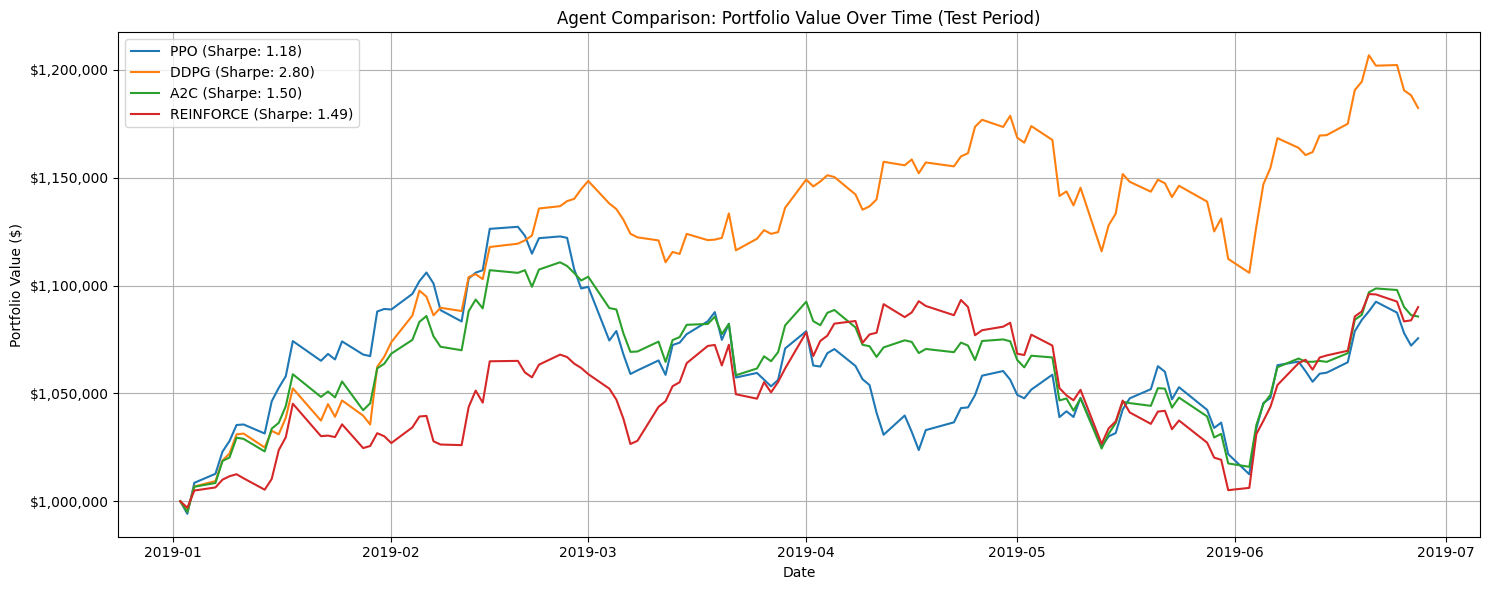

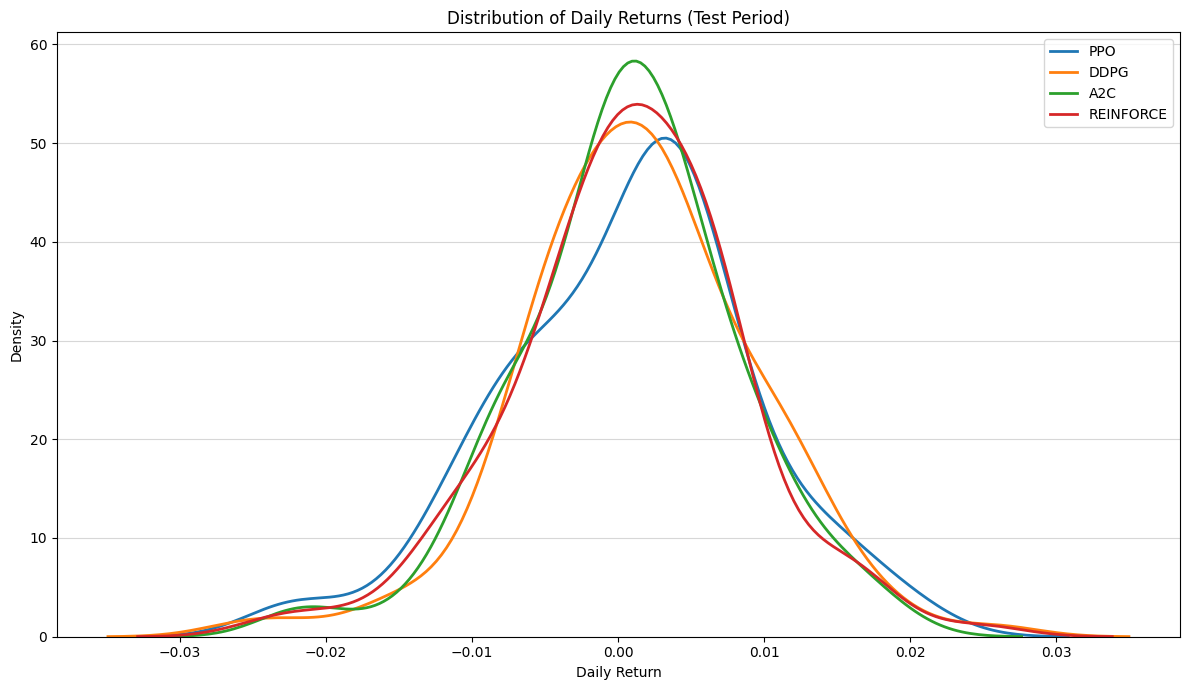

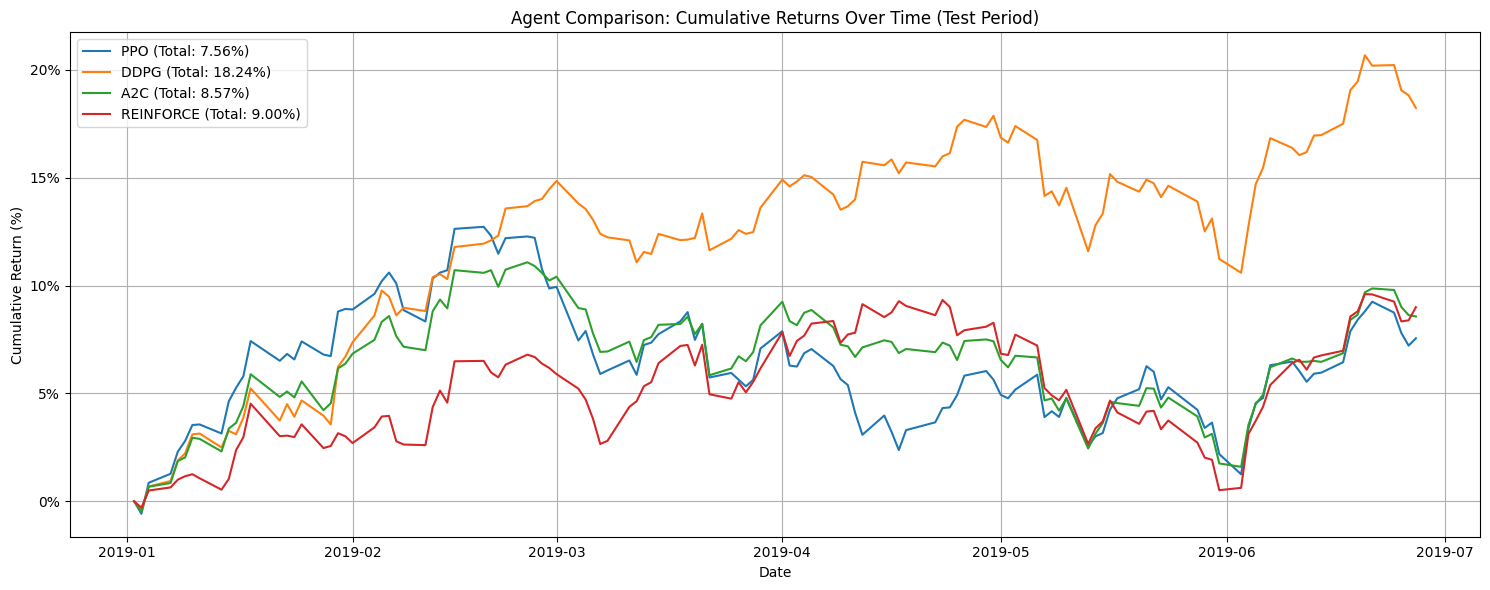

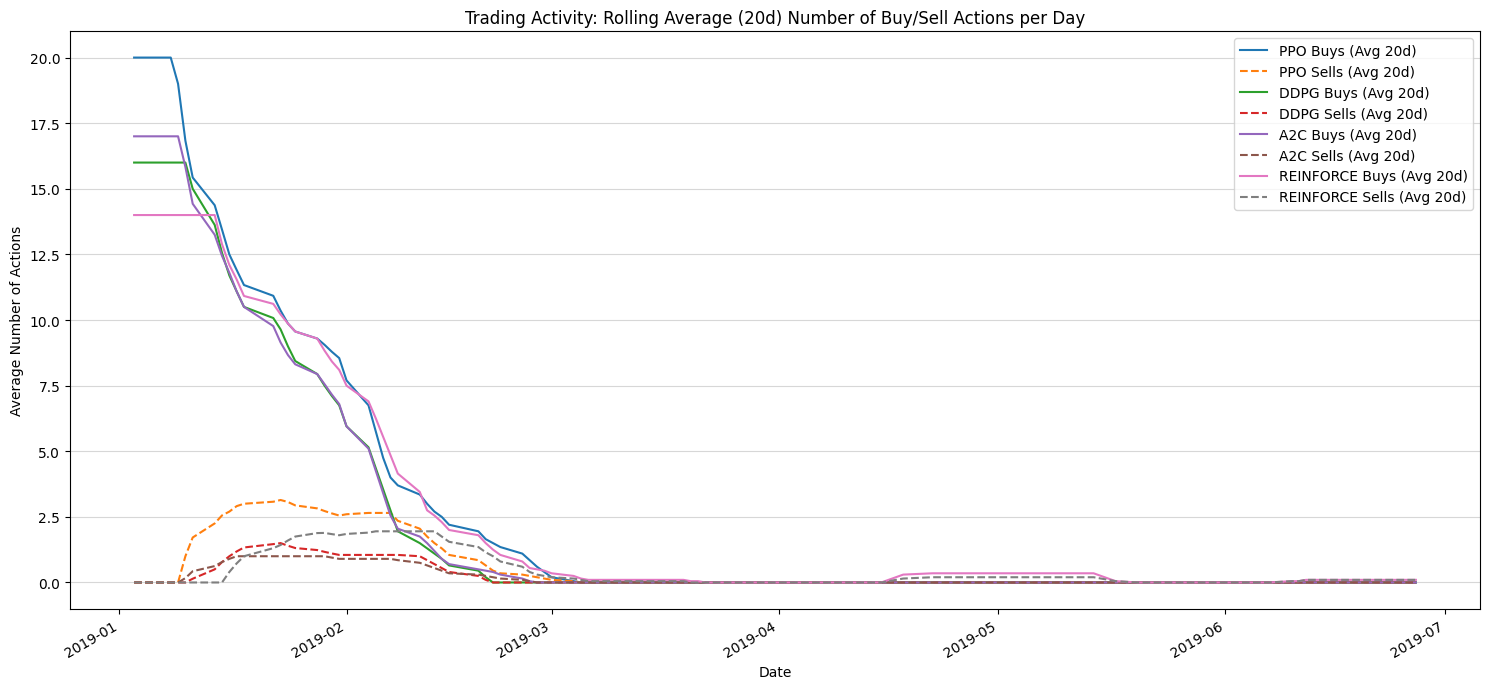

In [76]:
# --- Testing Script Modifications ---

# ... (Imports, data loading, ensure state_space=378 setup) ...

# --- 1) Rebuild the Test Environment (Code as before) ---
# test_env = StockTradingEnv(...) # state_space=378

# --- 2) Test Each Agent ---

agent_configs = {
    "PPO": {"class": PPOAgent, "path": ppo_model_path, "hidden": ppo_hidden_sizes, "dir": False, "needs_dims": True},
    "DDPG": {"class": DDPGAgent, "path": ddpg_model_dir, "hidden": ddpg_hidden_sizes, "dir": True, "needs_dims": False},
    "A2C": {"class": A2CAgent, "path": a2c_model_path, "hidden": a2c_hidden_sizes, "dir": False, "needs_dims": False},
    # *** ADD REINFORCE CONFIG ***
    "REINFORCE": {"class": REINFORCEAgent, "path": "reinforce_from_scratch.pth", "hidden": (64, 64), "dir": False, "needs_dims": True} # REINFORCE needs dims
}

current_state_dim = state_space # Should be 378
current_action_dim = action_space
results = {}

# --- (Instantiate, Load, Rollout loop - check instantiation logic) ---
for name, config in agent_configs.items():
    print(f"\n--- Testing {name} Agent ---")
    try:
        if config["needs_dims"]:
             # PPO and REINFORCE need explicit dims
             agent = config["class"](
                 state_dim=current_state_dim,
                 action_dim=current_action_dim,
                 env=test_env, # Pass env for bounds etc.
                 hidden_sizes=config["hidden"],
                 device=device
             )
        else:
             # DDPG, A2C infer from env
             agent = config["class"](
                 env=test_env,
                 hidden_sizes=config["hidden"],
                 device=device
             )
        print(f"{name} agent instantiated.")

    except TypeError as e:
         print(f"TypeError during {name} instantiation: {e}")
         continue
    except Exception as e:
        print(f"An unexpected error occurred during {name} instantiation: {e}")
        continue

    # Load weights (should handle reinforce_from_scratch.pth)
    try:
        # ... (loading logic as before) ...
         if config["dir"]:
             agent.load(config["path"])
         else:
             agent.load(config["path"])
         print(f"{name} model loaded successfully.")
    except Exception as e:
         # ... (error handling as before) ...
         print(f"ERROR during {name} model loading: {e}")
         continue

    # --- Rollout loop (uses agent.predict - REINFORCE predict uses mean) ---
    # ... (rollout logic as before) ...
    test_env.reset() # Reset env for each agent!
    out = test_env.state # Access state after reset
    state = out[0] if isinstance(out, tuple) else out
    state = np.asarray(state, dtype=np.float32) # Ensure correct type

    done = False
    while not done:
          try:
              action = agent.predict(state) # Use deterministic prediction
              step = test_env.step(action)

              if len(step) == 5:
                  obs, reward, term, trunc, info = step
                  done = bool(term or trunc)
              else:
                  obs, reward, done, info = step

              state = obs if not isinstance(obs, tuple) else obs[0]
              state = np.asarray(state, dtype=np.float32) # Ensure correct type
          except Exception as e:
              print(f"Error during {name} rollout step: {e}")
              done = True # Stop rollout for this agent on error

        # --- (Result extraction and calculation code as before) ---
        # Extract test results (only if rollout completed somewhat)
    if test_env.day > 0: # Check if at least one step was taken
        print(f"{name} rollout complete (or stopped due to error).")
        dates = pd.to_datetime(test_env.date_memory)
        assets = np.array(test_env.asset_memory)
        actions_df = test_env.save_action_memory() # Get actions DataFrame
        if len(assets) > 1:
            daily_rets = assets[1:] / assets[:-1] - 1
            total_return = assets[-1] / assets[0] - 1
            sharpe_ratio = (daily_rets.mean() / (daily_rets.std()+1e-8)) * np.sqrt(252) # Annualized Sharpe
            results[name] = {
                    "dates": dates,
                    "assets": assets,
                    "actions": actions_df,
                    "daily_returns": daily_rets,
                    "total_return": total_return,
                    "sharpe_ratio": sharpe_ratio
                }
            print(f"  Test: {dates[0].date()} -> {dates[-1].date()} | " f"Final=${assets[-1]:,.2f} | Return={total_return*100:.2f}% | Sharpe={sharpe_ratio:.2f}")
        else:
            print(f"  Warning: Not enough data points in asset memory for {name} to calculate metrics.")
    else:
          print(f"  {name} rollout did not complete enough steps for analysis.")


    # --- (Plotting code remains the same) ---
    # ...
    # --- 3) Comparison Plot (Portfolio Value) ---

    if results: # Check if any results were generated
        plt.figure(figsize=(15, 6))
        for name, data in results.items():
            plt.plot(data["dates"], data["assets"], label=f"{name} (Sharpe: {data['sharpe_ratio']:.2f})")

        plt.title("Agent Comparison: Portfolio Value Over Time (Test Period)")
        plt.xlabel("Date")
        plt.ylabel("Portfolio Value ($)")
        plt.legend()
        plt.grid(True)
        # Optional: Format y-axis as currency
        try:
            from matplotlib.ticker import FuncFormatter
            plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x:,.0f}"))
        except ImportError:
            print("Note: Optional currency formatting requires matplotlib.ticker")
        plt.tight_layout()
        plt.show()

        # --- 4) Additional Relevant Plots ---

        # Plot 1: Daily Returns Distribution (Histogram or KDE)
        plt.figure(figsize=(12, 7))
        for name, data in results.items():
            sns.kdeplot(data["daily_returns"], label=f"{name}", lw=2)
            # Or use histogram:
            # plt.hist(data["daily_returns"], bins=50, alpha=0.6, label=f"{name}")

        plt.title("Distribution of Daily Returns (Test Period)")
        plt.xlabel("Daily Return")
        plt.ylabel("Density") # Or "Frequency" if using hist
        plt.legend()
        plt.grid(True, axis='y', alpha=0.5)
        plt.tight_layout()
        plt.show()

        # Plot 2: Cumulative Returns
        plt.figure(figsize=(15, 6))
        for name, data in results.items():
            cumulative_returns = (data["assets"] / data["assets"][0]) - 1
            plt.plot(data["dates"], cumulative_returns * 100, label=f"{name} (Total: {data['total_return']*100:.2f}%)")

        plt.title("Agent Comparison: Cumulative Returns Over Time (Test Period)")
        plt.xlabel("Date")
        plt.ylabel("Cumulative Return (%)")
        plt.legend()
        plt.grid(True)
        # Format y-axis as percentage
        try:
            from matplotlib.ticker import FuncFormatter
            plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))
        except ImportError:
             print("Note: Optional percentage formatting requires matplotlib.ticker")

        plt.tight_layout()
        plt.show()


        # Plot 3: Trading Activity (Buy/Sell/Hold Count per Day)
        # This requires processing the actions_df for each agent
        # Plot 3: Trading Activity (Buy/Sell/Hold Count per Day)
        plt.figure(figsize=(15, 7))
        n_agents = len(results)
        # bar_width = 0.8 / n_agents # Not needed for line plot

        for i, (name, data) in enumerate(results.items()):
            # Check if required data exists
            if "actions" not in data or data["actions"].empty or \
               "dates" not in data or len(data["dates"]) < 2:
                print(f"Skipping trading activity plot for {name}: Missing or insufficient action/date data.")
                continue

            actions = data["actions"].copy() # Work on a copy
            buy_threshold = 0.01
            sell_threshold = -0.01

            # Count actions per step (date) - sum across stocks
            # This Series should have length T (e.g., 122)
            daily_buys = (actions > buy_threshold).sum(axis=1)
            daily_sells = (actions < sell_threshold).sum(axis=1)
            # daily_holds = action_space - buys - sells # Not plotted

            # --- FIX: Align Dates and Actions ---
            # date_memory has T+1 dates, action data has T steps.
            # Use dates starting from the second day to match the action steps.
            if len(data["dates"]) == len(daily_buys) + 1:
                dates_for_plot = data["dates"][1:] # Shape should now be (T,) e.g., (122,)
            elif len(data["dates"]) == len(daily_buys):
                # If somehow lengths already match
                print(f"Note: Dates and actions length match unexpectedly for {name}. Using all dates.")
                dates_for_plot = data["dates"]
            else:
                print(f"Warning: Cannot align dates (len {len(data['dates'])}) and daily actions (len {len(daily_buys)}) for {name}. Skipping activity plot.")
                continue
            # --- End Fix ---


            # Alternative: Line plot of rolling average activity
            rolling_window = 20 # e.g., 20 trading days

            # Check if enough data for the rolling window
            if len(daily_buys) >= rolling_window:
                # Use min_periods=1 to avoid NaNs at the beginning just due to window size
                # The rolling Series will still have length T (e.g., 122)
                rolling_buys_mean = daily_buys.rolling(rolling_window, min_periods=1).mean()
                rolling_sells_mean = daily_sells.rolling(rolling_window, min_periods=1).mean()

                # Plot using the aligned dates_for_plot (length T) and rolling means (length T)
                plt.plot(dates_for_plot, rolling_buys_mean, label=f'{name} Buys (Avg {rolling_window}d)', linestyle='-')
                plt.plot(dates_for_plot, rolling_sells_mean, label=f'{name} Sells (Avg {rolling_window}d)', linestyle='--')
            elif len(daily_buys) > 0 : # Plot raw if not enough for rolling
                print(f"Warning: Not enough data points ({len(daily_buys)}) for rolling window ({rolling_window}) for {name}. Plotting raw counts.")
                plt.plot(dates_for_plot, daily_buys, label=f'{name} Buys (Raw)', linestyle='-')
                plt.plot(dates_for_plot, daily_sells, label=f'{name} Sells (Raw)', linestyle='--')
            else:
                print(f"Skipping activity plot for {name}: No daily action data.")


        # Configure plot appearance (only if anything was plotted)
        # Check if the axes actually contain any lines before setting labels/titles
        if plt.gca().has_data():
            plt.title(f"Trading Activity: Rolling Average ({rolling_window}d) Number of Buy/Sell Actions per Day")
            plt.xlabel("Date")
            plt.ylabel("Average Number of Actions")
            plt.legend(loc='best') # Let matplotlib decide best location
            plt.grid(True, axis='y', alpha=0.5)
            try:
                 plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
                 plt.gcf().autofmt_xdate() # Rotate dates
            except Exception:
                pass # Ignore formatting errors if they occur
            plt.tight_layout()
            plt.show()
        else:
             plt.close() # Close the empty figure if nothing was plotted
             print("Activity plot skipped as no agents had sufficient data.")
    # --- Result extraction (as before) ---
    # ... (store results in `results` dict) ...

# --- Plotting (Code as before - will automatically include REINFORCE) ---
# ... (Plots will now include REINFORCE results if testing was successful) ...